# Préparation, nettoyage et visualisation du corpus Telegram

Ce notebook prépare le corpus Telegram utilisé dans l’analyse des déplacements forcés d’Ukraine vers la Russie. Il sert à explorer la structure initiale des données, à visualiser la répartition des espaces de communication, puis à nettoyer les exports Telegram afin de produire un corpus textuel exploitable.

Au début de la recherche, l’analyse a été envisagée à partir de deux types d’espaces : d’une part, des chats de discussion générale liés à l’aide aux personnes déplacées ; d’autre part, des chaînes et chats associés à des organisations ou initiatives bénévoles. Dans un second temps, le corpus principal de l’analyse a été resserré aux chats de discussion.

Le notebook suit donc quatre objectifs principaux :

1. décrire la structure générale des fichiers Telegram ;
2. visualiser la distribution régionale et temporelle des chats ;
3. nettoyer les textes issus des exports JSON ;
4. produire une première visualisation lexicale du corpus nettoyé.

In [1]:
import math
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt

In [ ]:
corpus = pd.read_csv(
    "corpus_telegram.csv",
    sep=",",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)
corpus 

In [2]:
#combien de fichiers dans le dossier
path = Path("/Users/quentinnippert/Documents/mm_files/Telegram_analyse/telegram_messages_data")
files = list(path.glob("*.json"))
print(f"Nombre de fichiers JSON dans le dossier: {len(files)}")

Nombre de fichiers JSON dans le dossier: 133


## 1. Exploration générale du corpus Telegram

Cette première partie donne une vue d’ensemble des fichiers Telegram exportés au format JSON. Elle sert à vérifier la composition du corpus avant nettoyage : nombre d’espaces de communication, distribution par région, volume de messages et période d’activité.

Le corpus a d’abord été envisagé de manière large, en incluant à la fois des chats de discussion liés aux personnes déplacées et des espaces associés à l’activité bénévole. Dans la suite de l’analyse, seuls les chats de discussion ont été conservés comme corpus principal, car ils permettent d’observer plus directement les interactions, les demandes d’aide, les réponses pratiques et les formulations ordinaires des acteurs.

### 1.1. Chats de discussion générale

Ce bloc concerne les chats Telegram dans lesquels circulent des demandes d’aide, des informations pratiques et des échanges entre personnes concernées par les déplacements depuis l’Ukraine vers la Russie. Ces espaces constituent le cœur du corpus Telegram retenu pour l’analyse finale.

#### Préparation des fichiers

Les fichiers sont organisés dans des dossiers régionaux. Le notebook commence par définir le dossier source contenant les exports Telegram, puis parcourt les sous-dossiers afin de compter les fichiers disponibles.

#### Statistiques générales sur les fichiers

Cette section calcule le nombre de fichiers JSON par région et produit une première visualisation de leur distribution. Elle permet d’identifier les régions les plus représentées dans le corpus et d’évaluer l’équilibre général des données.

In [2]:
ROOT_FOLDER = Path("chats_orig")

Statistique : nombre de fichiers JSON par dossier

Niveau_federal_(Russie): 10
Oblast_de_Rostov: 7
Krai_de_Krasnodar: 6
Crimee: 4
Oblast_de_Belgorod: 3
Krai_de_Krasnoïarsk: 1
Krai_de_Perm: 1
Kraï_de_Khabarovsk: 1
Oblast_de_Nijni_Novgorod: 1
Oblast_de_Penza: 1
Oblast_de_Sverdlovsk: 1
Oblast_de_Tcheliabinsk: 1
Oblast_de_Tioumen: 1
Oblast_de_Volgograd: 1
Oblast_de_Voronej: 1
Republique_dOudmourtie: 1

Total de fichiers JSON: 41
Nombre de dossiers: 16


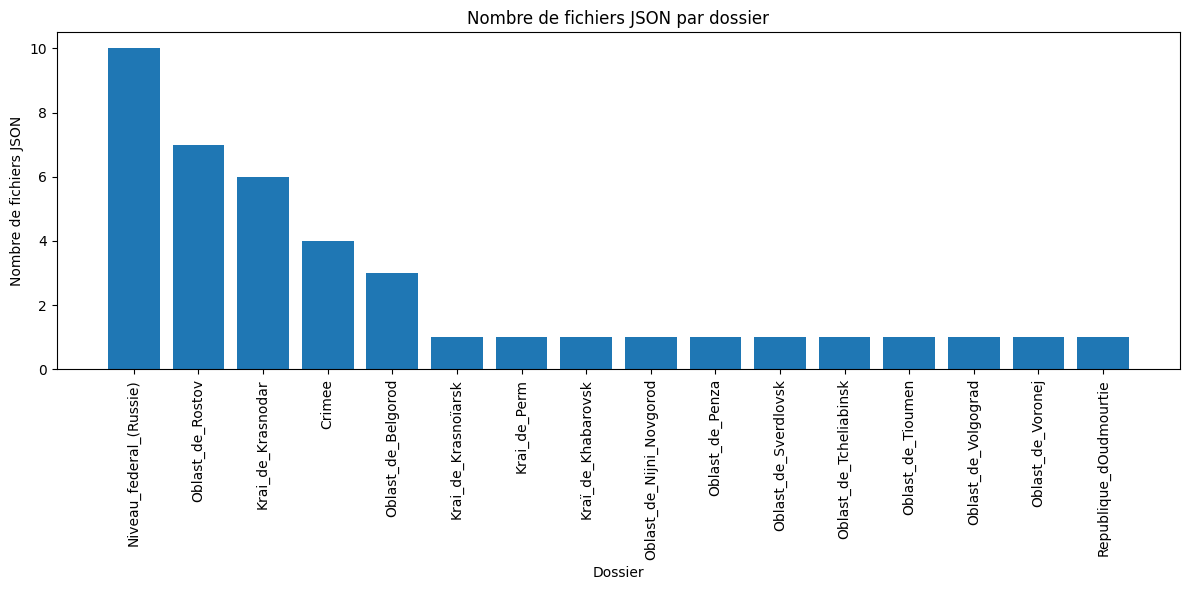

In [3]:
#1. Quels regions sont présentent dans le corpus ?
#2. Combien de l'espaces de communication (chats) pour chaque région ?

subfolders = sorted([p for p in ROOT_FOLDER.iterdir() if p.is_dir()], key=lambda x: x.name.lower())

stats = []
for folder in subfolders:
    json_count = len(list(folder.glob("*.json")))
    stats.append((folder.name, json_count))

stats = sorted(stats, key=lambda x: x[1], reverse=True)


print("Statistique : nombre de fichiers JSON par dossier\n")
total_files = 0
for folder_name, count in stats:
    print(f"{folder_name}: {count}")
    total_files += count

print(f"\nTotal de fichiers JSON: {total_files}")
print(f"Nombre de dossiers: {len(stats)}")

# Гистограмма

folder_names = [x[0] for x in stats]
file_counts = [x[1] for x in stats]

plt.figure(figsize=(12, 6))
plt.bar(folder_names, file_counts)
plt.xticks(rotation=90)
plt.ylabel("Nombre de fichiers JSON")
plt.xlabel("Dossier")
plt.title("Nombre de fichiers JSON par dossier")
plt.tight_layout()
plt.show()


Statistique : nombre de messages par fichier et somme par dossier

Oblast_de_Rostov:
  assistance_shakhty.json - 508404
  refugies_rostov.json - 84374
  rostov_bienveillant.json - 30061
  discussion_de_la_collecte_deux_coeurs.json - 8437
  refugies_rpd_rpl_a_rostov.json - 4137
  nouveaux_arriv_shakhty.json - 1815
  assistance_articles.json - 571
  SOMME: 637799

Niveau_federal_(Russie):
  plateforme_dinformation_chat.json - 145067
  refugies_en_russie_chat.json - 111076
  les_personnes_deplacees_de_kharkiv.json - 89992
  refugiees_russie_chat.json - 27244
  refugies_en_russie_RU.json - 26507
  nous_vivrons_chat.json - 21745
  assistance_aux_refugies_du_donbass.json - 11780
  donbass_en_russie_chat.json - 9890
  question_responses_assistance_informatique.json - 6229
  le_monde_pour_tous_chat.json - 5336
  SOMME: 454866

Crimee:
  refugees_crimee.json - 66302
  refugees_simpheropol.json - 55191
  refugees_sevastopol.json - 38250
  cher_crimee.json - 4219
  SOMME: 163962

Krai_de_Krasnoda

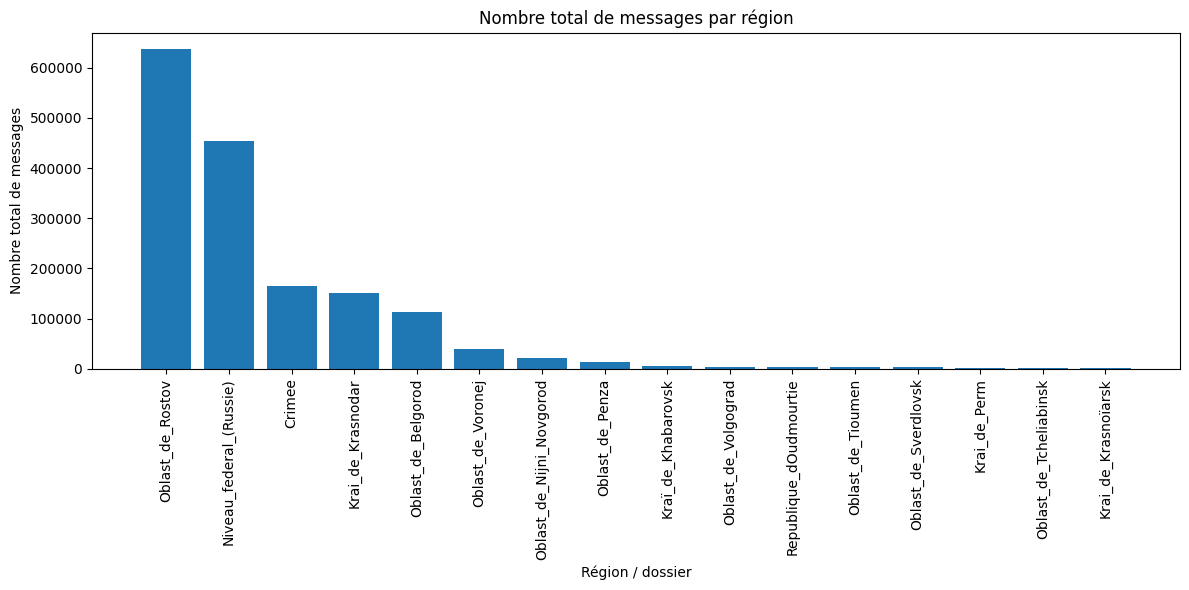

In [27]:
def extract_entries(obj):
    if isinstance(obj, list):
        return obj

    if isinstance(obj, dict):
        preferred_keys = ["messages", "entries", "items", "results", "data"]
        for key in preferred_keys:
            if key in obj:
                value = obj[key]
                if isinstance(value, list):
                    return value
                if isinstance(value, dict):
                    nested = extract_entries(value)
                    if nested is not None:
                        return nested

        for value in obj.values():
            nested = extract_entries(value)
            if nested is not None:
                return nested

    return None

def count_entries_in_json(json_path):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        entries = extract_entries(data)
        return len(entries) if entries is not None else 0
    except Exception as e:
        print(f"Erreur avec {json_path.name}: {e}")
        return 0

subfolders = sorted(
    [p for p in ROOT_FOLDER.iterdir() if p.is_dir()],
    key=lambda x: x.name.lower()
)

folder_reports = []
grand_total_entries = 0

for folder in subfolders:
    json_files = sorted(folder.glob("*.json"), key=lambda x: x.name.lower())

    file_stats = []
    total_entries_in_folder = 0

    for json_file in json_files:
        count = count_entries_in_json(json_file)
        file_stats.append((json_file.name, count))
        total_entries_in_folder += count

    # сортировка файлов внутри папки по числу сообщений
    file_stats = sorted(file_stats, key=lambda x: x[1], reverse=True)

    folder_reports.append({
        "folder_name": folder.name,
        "file_stats": file_stats,
        "folder_sum": total_entries_in_folder
    })

    grand_total_entries += total_entries_in_folder

# сортировка папок по сумме
folder_reports = sorted(folder_reports, key=lambda x: x["folder_sum"], reverse=True)

print("Statistique : nombre de messages par fichier et somme par dossier\n")

for report in folder_reports:
    print(f'{report["folder_name"]}:')
    for file_name, count in report["file_stats"]:
        print(f"  {file_name} - {count}")
    print(f'  SOMME: {report["folder_sum"]}\n')

print("Résumé général")
for report in folder_reports:
    print(f'{report["folder_name"]}: {report["folder_sum"]}')

print(f"\nTotal général d'entries: {grand_total_entries}")
print(f"Nombre de dossiers: {len(folder_reports)}")

# Гистограмма по суммам папок
folder_names = [report["folder_name"] for report in folder_reports]
entry_counts = [report["folder_sum"] for report in folder_reports]

plt.figure(figsize=(12, 6))
plt.bar(folder_names, entry_counts)
plt.xticks(rotation=90)
plt.ylabel("Nombre total de messages")
plt.xlabel("Région / dossier")
plt.title("Nombre total de messages par région")
plt.tight_layout()
plt.show()

In [4]:
# Quand est ce que ces chats étaient actifs ? (premier et dernier message)

def first_last_message_dates(json_path):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data["messages"]

        dates = []
        for message in messages:
            if "date" in message and message["date"]:
                dt = pd.to_datetime(message["date"], errors="coerce")
                if pd.notna(dt):
                    dates.append(dt)

        if not dates:
            return None, None

        return min(dates), max(dates)

    except Exception as e:
        print(f"Erreur avec {json_path.name}: {e}")
        return None, None


subfolders = sorted(
    [p for p in ROOT_FOLDER.iterdir() if p.is_dir()],
    key=lambda x: x.name.lower()
)

print("Statistique : première et dernière date de message par fichier\n")

total_folders = 0
total_files = 0
files_with_dates = 0

for folder in subfolders:
    json_files = sorted(folder.glob("*.json"), key=lambda x: x.name.lower())
    if not json_files:
        continue

    total_folders += 1
    total_files += len(json_files)

    print(f"{folder.name}:")
    max_len = max(len(jf.name) for jf in json_files)

    for json_file in json_files:
        first_dt, last_dt = first_last_message_dates(json_file)

        if first_dt is not None and last_dt is not None:
            files_with_dates += 1
            first_str = first_dt.strftime("%Y-%m-%d %H:%M:%S")
            last_str = last_dt.strftime("%Y-%m-%d %H:%M:%S")
        else:
            first_str = "date non trouvée"
            last_str = "date non trouvée"

        print(
            f"    {json_file.name:<{max_len}}    "
            f"premier message: {first_str}    "
            f"dernier message: {last_str}"
        )

    print()

print("Résumé")
print(f"    Dossiers analysés: {total_folders}")
print(f"    Fichiers analysés: {total_files}")
print(f"    Fichiers avec dates trouvées: {files_with_dates}")
print(f"    Fichiers sans dates trouvées: {total_files - files_with_dates}")

Statistique : première et dernière date de message par fichier

Crimee:
    cher_crimee.json             premier message: 2022-12-23 08:25:39    dernier message: 2025-11-12 14:31:20
    refugees_crimee.json         premier message: 2022-03-21 09:56:03    dernier message: 2025-11-12 18:54:04
    refugees_sevastopol.json     premier message: 2022-03-28 14:58:50    dernier message: 2025-11-12 18:54:35
    refugees_simpheropol.json    premier message: 2022-03-28 14:59:42    dernier message: 2025-11-12 20:33:03

Krai_de_Krasnodar:
    assistance_krasnodar.json       premier message: 2022-03-22 12:15:54    dernier message: 2025-09-25 16:44:10
    assistance_novorossiysk.json    premier message: 2022-04-02 07:15:01    dernier message: 2025-11-12 19:31:13
    assistance_sotchi.json          premier message: 2022-07-25 13:45:47    dernier message: 2024-06-02 13:42:25
    assistance_tuapse.json          premier message: 2022-11-08 10:52:48    dernier message: 2025-11-05 19:15:54
    centre_krasn

#### Temporalité d’activité des chats

Les cellules suivantes identifient la première et la dernière date de message pour chaque fichier, puis visualisent la période d’activité des chats. Cette étape permet de repérer les espaces actifs sur une longue durée et ceux qui sont liés à des moments plus ponctuels de la mobilisation.

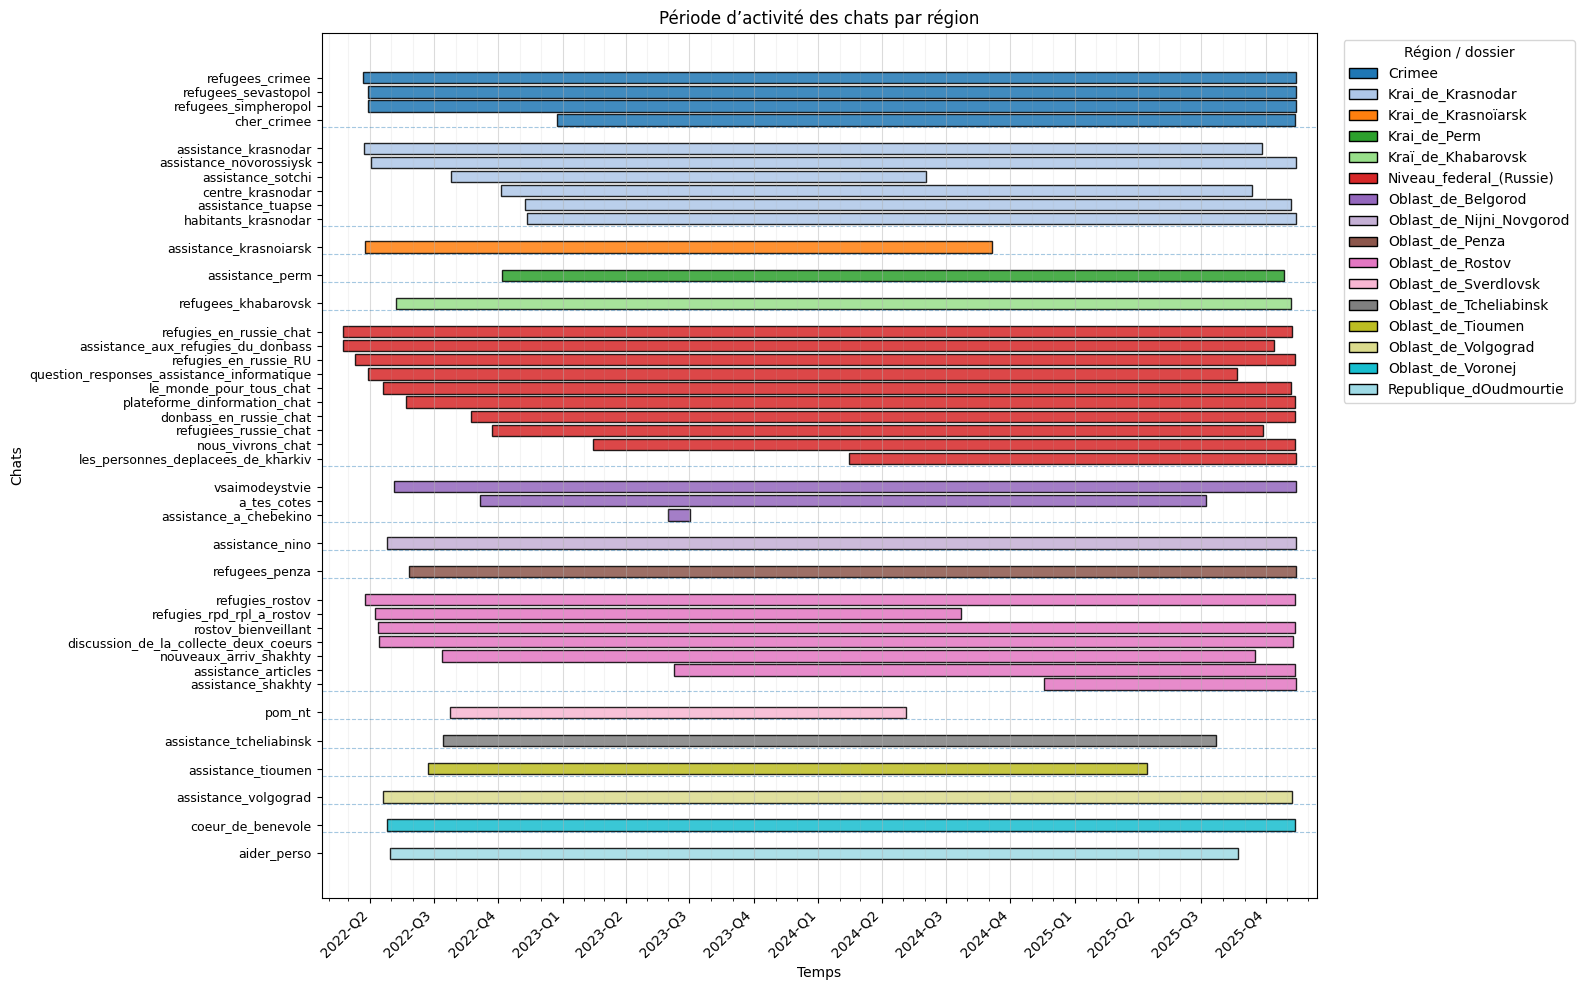

In [5]:
# Visualisation de la période d’activité des chats par région

import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

folder_data = []

for folder in subfolders:
    json_files = sorted(folder.glob("*.json"), key=lambda x: x.name.lower())
    chats = []

    for json_file in json_files:
        first_dt, last_dt = first_last_message_dates(json_file)

        if first_dt is not None and last_dt is not None:
            chats.append({
                "chat_name": json_file.stem,
                "start": first_dt,
                "end": last_dt
            })

    chats = sorted(chats, key=lambda x: x["start"])

    if chats:
        folder_data.append({
            "folder_name": folder.name,
            "chats": chats
        })

if not folder_data:
    print("Aucune donnée temporelle trouvée.")
else:
    cmap = plt.get_cmap("tab20", len(folder_data))
    folder_colors = {
        folder_data[i]["folder_name"]: cmap(i)
        for i in range(len(folder_data))
    }

    fig, ax = plt.subplots(figsize=(16, 10))

    y_positions = []
    y_labels = []
    group_separators = []

    current_y = 0
    all_starts = []
    all_ends = []

    for folder_item in folder_data:
        folder_name = folder_item["folder_name"]
        chats = folder_item["chats"]

        for chat in chats:
            start_num = mdates.date2num(chat["start"])
            end_num = mdates.date2num(chat["end"])

            ax.barh(
                y=current_y,
                width=end_num - start_num,
                left=start_num,
                height=0.8,
                color=folder_colors[folder_name],
                edgecolor="black",
                alpha=0.85
            )

            y_positions.append(current_y)
            y_labels.append(chat["chat_name"])
            all_starts.append(chat["start"])
            all_ends.append(chat["end"])

            current_y += 1

        group_separators.append(current_y - 0.5)
        current_y += 1  # espace entre dossiers

    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=9)

    global_start = min(all_starts)
    global_end = max(all_ends)
    pad = pd.Timedelta(days=30)
    ax.set_xlim(global_start - pad, global_end + pad)

    # Axe X : ticks principaux par trimestre, ticks secondaires par mois
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    def quarter_formatter(x, pos):
        dt = mdates.num2date(x)
        quarter = (dt.month - 1) // 3 + 1
        return f"{dt.year}-Q{quarter}"

    ax.xaxis.set_major_formatter(FuncFormatter(quarter_formatter))

    # séparateurs entre régions
    for sep in group_separators[:-1]:
        ax.axhline(sep, linestyle="--", linewidth=0.8, alpha=0.4)

    legend_elements = [
        Patch(facecolor=folder_colors[name], edgecolor="black", label=name)
        for name in folder_colors
    ]
    ax.legend(
        handles=legend_elements,
        title="Région / dossier",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.set_xlabel("Temps")
    ax.set_ylabel("Chats")
    ax.set_title("Période d’activité des chats par région")

    # Сетка: кварталы и месяцы
    ax.grid(axis="x", which="major", alpha=0.45)
    ax.grid(axis="x", which="minor", alpha=0.15)

    ax.invert_yaxis()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

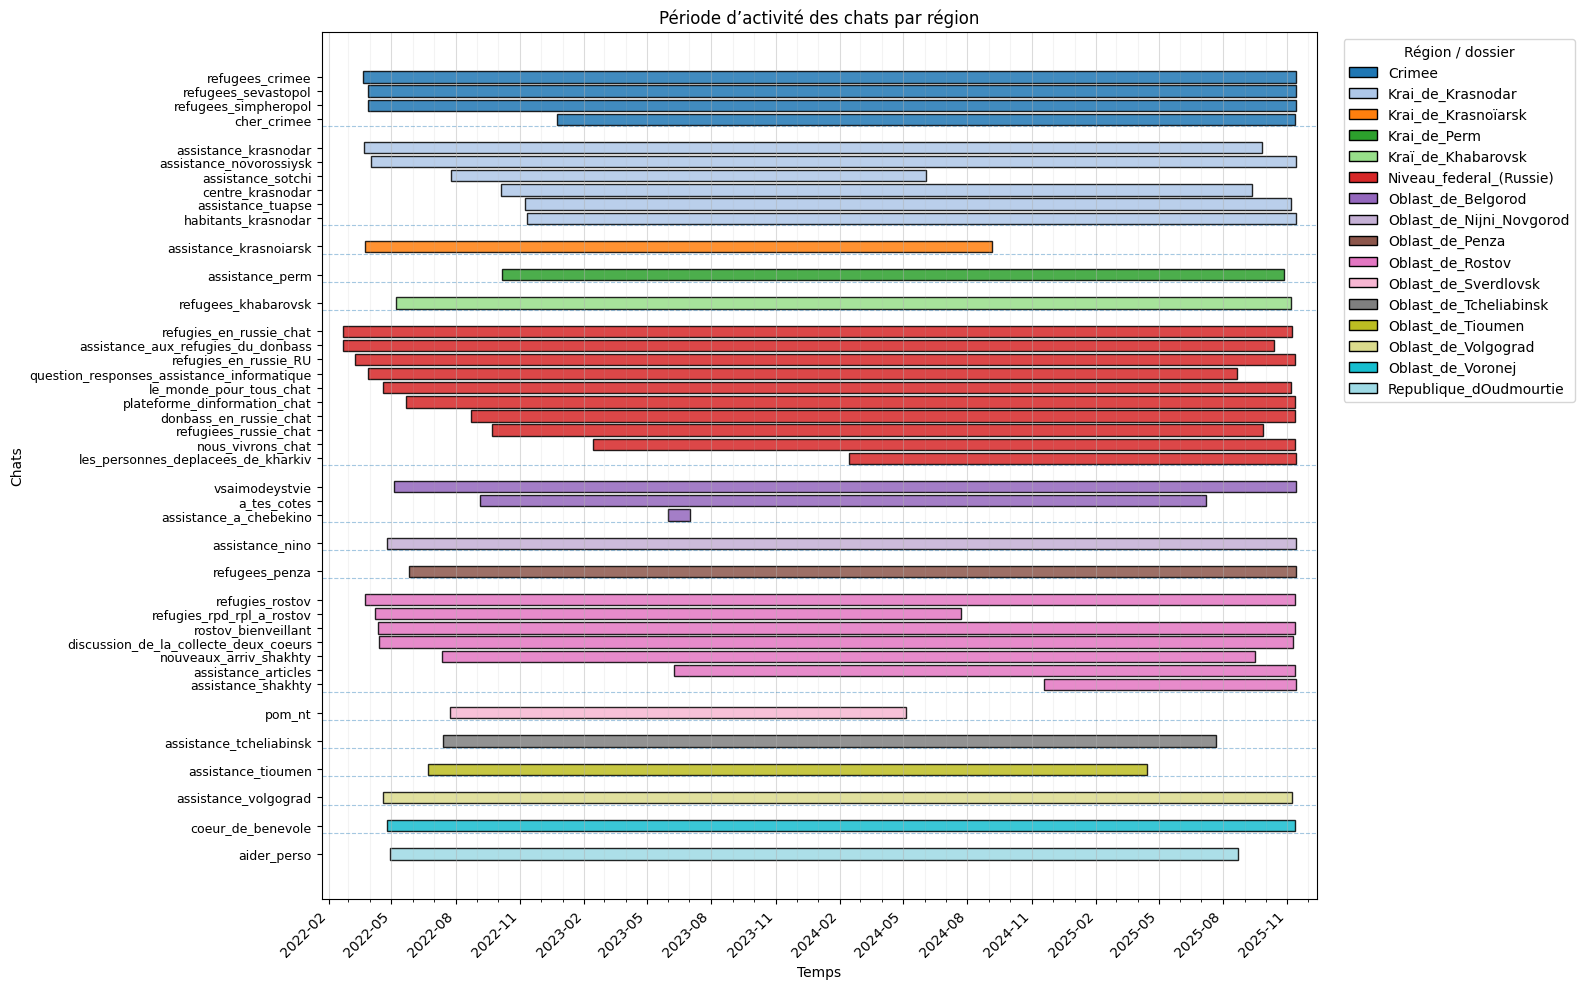

Début du corpus : 2022-02-20 11:37:03
Fin du corpus : 2025-11-12 23:59:42


In [10]:
# Visualisation de la période d’activité des chats par région

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
import pandas as pd

folder_data = []

for folder in subfolders:
    json_files = sorted(folder.glob("*.json"), key=lambda x: x.name.lower())
    chats = []

    for json_file in json_files:
        first_dt, last_dt = first_last_message_dates(json_file)

        if first_dt is not None and last_dt is not None:
            chats.append({
                "chat_name": json_file.stem,
                "start": pd.to_datetime(first_dt),
                "end": pd.to_datetime(last_dt)
            })

    chats = sorted(chats, key=lambda x: x["start"])

    if chats:
        folder_data.append({
            "folder_name": folder.name,
            "chats": chats
        })

if not folder_data:
    print("Aucune donnée temporelle trouvée.")

else:
    cmap = plt.get_cmap("tab20", len(folder_data))
    folder_colors = {
        folder_data[i]["folder_name"]: cmap(i)
        for i in range(len(folder_data))
    }

    fig, ax = plt.subplots(figsize=(16, 10))

    y_positions = []
    y_labels = []
    group_separators = []

    current_y = 0
    all_starts = []
    all_ends = []

    for folder_item in folder_data:
        folder_name = folder_item["folder_name"]
        chats = folder_item["chats"]

        for chat in chats:
            start_num = mdates.date2num(chat["start"])
            end_num = mdates.date2num(chat["end"])

            ax.barh(
                y=current_y,
                width=end_num - start_num,
                left=start_num,
                height=0.8,
                color=folder_colors[folder_name],
                edgecolor="black",
                alpha=0.85
            )

            y_positions.append(current_y)
            y_labels.append(chat["chat_name"])
            all_starts.append(chat["start"])
            all_ends.append(chat["end"])

            current_y += 1

        group_separators.append(current_y - 0.5)
        current_y += 1

    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=9)

    global_start = min(all_starts)
    global_end = max(all_ends)

    # limites exactes + marge visuelle
    pad = pd.Timedelta(days=30)
    x_min = global_start - pad
    x_max = global_end + pad

    ax.set_xlim(
        mdates.date2num(x_min),
        mdates.date2num(x_max)
    )

    # Premier et dernier mois du corpus
    first_month_tick = global_start.to_period("M").start_time
    last_month_tick = global_end.to_period("M").start_time

# Ticks tous les 3 mois à partir du premier mois
    ticks = list(pd.date_range(
        start=first_month_tick,
        end=last_month_tick,
        freq="3MS"
    ))

# Обязательно добавляем последний месяц, если он не попал в шаг 3 месяца
    if last_month_tick not in ticks:
        ticks.append(last_month_tick)

    ticks = sorted(set(ticks))

    ax.set_xticks([mdates.date2num(t) for t in ticks])

    def month_formatter(x, pos):
        dt = pd.Timestamp(mdates.num2date(x)).tz_localize(None)
        return dt.strftime("%Y-%m")

    ax.xaxis.set_major_formatter(FuncFormatter(month_formatter))

# Minor ticks каждый месяц
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    for sep in group_separators[:-1]:
        ax.axhline(sep, linestyle="--", linewidth=0.8, alpha=0.4)

    legend_elements = [
        Patch(facecolor=folder_colors[name], edgecolor="black", label=name)
        for name in folder_colors
    ]

    ax.legend(
        handles=legend_elements,
        title="Région / dossier",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.set_xlabel("Temps")
    ax.set_ylabel("Chats")
    ax.set_title("Période d’activité des chats par région")

    ax.grid(axis="x", which="major", alpha=0.45)
    ax.grid(axis="x", which="minor", alpha=0.15)

    ax.invert_yaxis()
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig("periode_activite_chats_par_region.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Début du corpus :", global_start)
    print("Fin du corpus :", global_end)

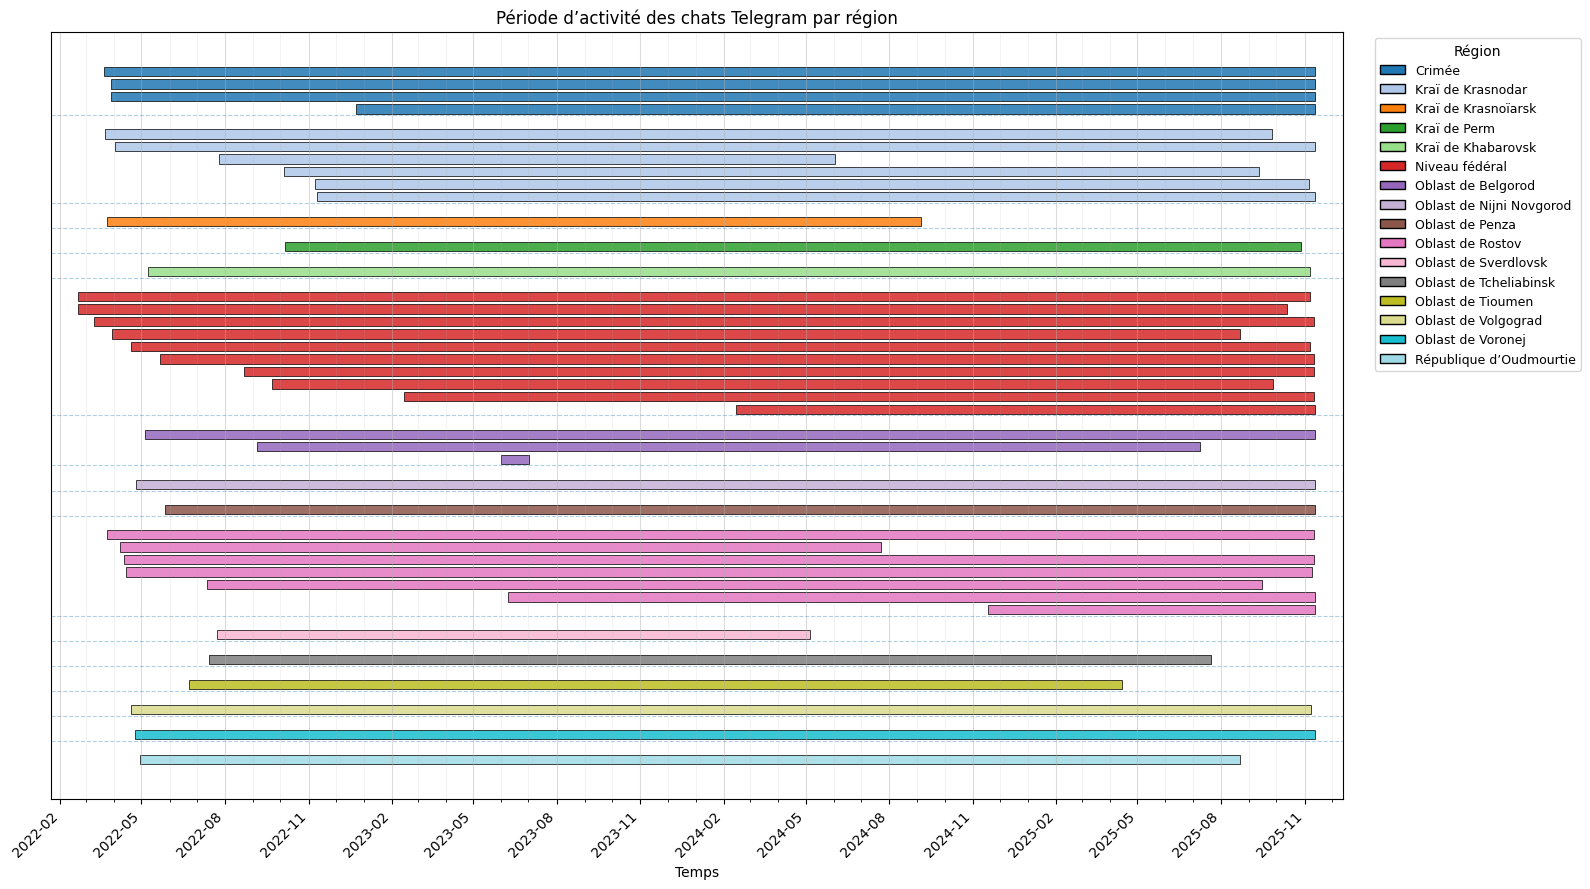

Début du corpus : 2022-02-20 11:37:03
Fin du corpus : 2025-11-12 23:59:42


In [5]:
# Visualisation de la période d’activité des chats par région
# Version simplifiée : sans noms des chats à gauche

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
import pandas as pd

# Красивые названия регионов
region_labels = {
    "Crimee": "Crimée",
    "Krai_de_Krasnodar": "Kraï de Krasnodar",
    "Krai_de_Krasnoïarsk": "Kraï de Krasnoïarsk",
    "Krai_de_Perm": "Kraï de Perm",
    "Kraï_de_Khabarovsk": "Kraï de Khabarovsk",
    "Niveau_federal_(Russie)": "Niveau fédéral",
    "Oblast_de_Belgorod": "Oblast de Belgorod",
    "Oblast_de_Nijni_Novgorod": "Oblast de Nijni Novgorod",
    "Oblast_de_Penza": "Oblast de Penza",
    "Oblast_de_Rostov": "Oblast de Rostov",
    "Oblast_de_Sverdlovsk": "Oblast de Sverdlovsk",
    "Oblast_de_Tcheliabinsk": "Oblast de Tcheliabinsk",
    "Oblast_de_Tioumen": "Oblast de Tioumen",
    "Oblast_de_Volgograd": "Oblast de Volgograd",
    "Oblast_de_Voronej": "Oblast de Voronej",
    "Republique_dOudmourtie": "République d’Oudmourtie",
}

folder_data = []

for folder in subfolders:
    json_files = sorted(folder.glob("*.json"), key=lambda x: x.name.lower())
    chats = []

    for json_file in json_files:
        first_dt, last_dt = first_last_message_dates(json_file)

        if first_dt is not None and last_dt is not None:
            chats.append({
                "chat_name": json_file.stem,
                "start": pd.to_datetime(first_dt),
                "end": pd.to_datetime(last_dt)
            })

    chats = sorted(chats, key=lambda x: x["start"])

    if chats:
        folder_data.append({
            "folder_name": folder.name,
            "region_label": region_labels.get(folder.name, folder.name),
            "chats": chats
        })

if not folder_data:
    print("Aucune donnée temporelle trouvée.")

else:
    cmap = plt.get_cmap("tab20", len(folder_data))

    folder_colors = {
        folder_data[i]["folder_name"]: cmap(i)
        for i in range(len(folder_data))
    }

    fig, ax = plt.subplots(figsize=(16, 9))

    group_separators = []
    group_centers = []
    group_labels = []

    current_y = 0
    all_starts = []
    all_ends = []

    for folder_item in folder_data:
        folder_name = folder_item["folder_name"]
        region_label = folder_item["region_label"]
        chats = folder_item["chats"]

        group_start_y = current_y

        for chat in chats:
            start_num = mdates.date2num(chat["start"])
            end_num = mdates.date2num(chat["end"])

            ax.barh(
                y=current_y,
                width=end_num - start_num,
                left=start_num,
                height=0.75,
                color=folder_colors[folder_name],
                edgecolor="black",
                linewidth=0.6,
                alpha=0.85
            )

            all_starts.append(chat["start"])
            all_ends.append(chat["end"])

            current_y += 1

        group_end_y = current_y - 1
        group_centers.append((group_start_y + group_end_y) / 2)
        group_labels.append(region_label)

        group_separators.append(current_y - 0.5)
        current_y += 1

    # Вариант 1: вообще убрать подписи слева
    ax.set_yticks([])

    # Вариант 2, если хочешь видеть только регионы слева, раскомментируй:
    # ax.set_yticks(group_centers)
    # ax.set_yticklabels(group_labels, fontsize=9)

    global_start = min(all_starts)
    global_end = max(all_ends)

    pad = pd.Timedelta(days=30)
    x_min = global_start - pad
    x_max = global_end + pad

    ax.set_xlim(
        mdates.date2num(x_min),
        mdates.date2num(x_max)
    )

    first_month_tick = global_start.to_period("M").start_time
    last_month_tick = global_end.to_period("M").start_time

    ticks = list(pd.date_range(
        start=first_month_tick,
        end=last_month_tick,
        freq="3MS"
    ))

    if last_month_tick not in ticks:
        ticks.append(last_month_tick)

    ticks = sorted(set(ticks))

    ax.set_xticks([mdates.date2num(t) for t in ticks])

    def month_formatter(x, pos):
        dt = pd.Timestamp(mdates.num2date(x)).tz_localize(None)
        return dt.strftime("%Y-%m")

    ax.xaxis.set_major_formatter(FuncFormatter(month_formatter))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    for sep in group_separators[:-1]:
        ax.axhline(sep, linestyle="--", linewidth=0.8, alpha=0.35)

    legend_elements = [
        Patch(
            facecolor=folder_colors[item["folder_name"]],
            edgecolor="black",
            label=item["region_label"]
        )
        for item in folder_data
    ]

    ax.legend(
        handles=legend_elements,
        title="Région",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        title_fontsize=10
    )

    ax.set_xlabel("Temps")
    ax.set_ylabel("")
    ax.set_title("Période d’activité des chats Telegram par région")

    ax.grid(axis="x", which="major", alpha=0.45)
    ax.grid(axis="x", which="minor", alpha=0.15)

    ax.invert_yaxis()
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig("periode_activite_chats_par_region_simplifie.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Début du corpus :", global_start)
    print("Fin du corpus :", global_end)

#### Cartographie exploratoire des chats par région

Cette visualisation cartographique représente la distribution géographique des chats Telegram. Les régions sont localisées à partir de coordonnées approximatives et la taille des marqueurs reflète le volume de messages. La carte sert à visualiser l’ancrage territorial du corpus et la concentration relative des échanges.

In [10]:
import pandas as pd
import folium

region_labels = {
    "Crimee": "Крым",
    "Krai_de_Krasnodar": "Краснодарский край",
    "Krai_de_Krasnoïarsk": "Красноярский край",
    "Krai_de_Perm": "Пермский край",
    "Kraï_de_Khabarovsk": "Хабаровский край",
    "Niveau_federal_(Russie)": "Федеральный уровень",
    "Oblast_de_Belgorod": "Белгородская область",
    "Oblast_de_Nijni_Novgorod": "Нижегородская область",
    "Oblast_de_Penza": "Пензенская область",
    "Oblast_de_Rostov": "Ростовская область",
    "Oblast_de_Sverdlovsk": "Свердловская область",
    "Oblast_de_Tcheliabinsk": "Челябинская область",
    "Oblast_de_Tioumen": "Тюменская область",
    "Oblast_de_Volgograd": "Волгоградская область",
    "Oblast_de_Voronej": "Воронежская область",
    "Republique_dOudmourtie": "Удмуртия",
}

telegram_coords = {
    "Крым": (45.3453, 34.4997),
    "Краснодарский край": (45.7684, 39.0261),
    "Красноярский край": (64.2479, 95.1104),
    "Пермский край": (58.8232, 56.5872),
    "Хабаровский край": (50.5888, 135.0000),
    "Белгородская область": (50.7080, 37.5838),
    "Нижегородская область": (56.2965, 43.9361),
    "Пензенская область": (53.1959, 45.0183),
    "Ростовская область": (47.6853, 41.8259),
    "Свердловская область": (58.6415, 61.8022),
    "Челябинская область": (54.4319, 60.8789),
    "Тюменская область": (57.8333, 69.0000),
    "Волгоградская область": (49.6048, 44.2904),
    "Воронежская область": (50.8589, 39.8644),
    "Удмуртия": (57.0670, 53.0278),
}

def count_json_messages(json_file):
    try:
        data = pd.read_json(json_file)
        return len(data)
    except Exception:
        try:
            data = pd.read_json(json_file, lines=True)
            return len(data)
        except Exception:
            return 0

rows = []

for folder in subfolders:
    folder_name = folder.name

    # исключаем федеральный уровень
    if folder_name == "Niveau_federal_(Russie)":
        continue

    region = region_labels.get(folder_name, folder_name)
    json_files = list(folder.glob("*.json"))

    n_chats = len(json_files)
    n_messages = sum(count_json_messages(f) for f in json_files)

    if region in telegram_coords:
        lat, lon = telegram_coords[region]

        rows.append({
            "region": region,
            "folder": folder_name,
            "lat": lat,
            "lon": lon,
            "n_chats": n_chats,
            "n_messages": n_messages,
        })

df_telegram_map = pd.DataFrame(rows)

In [12]:
m_messages = folium.Map(
    location=[52.0, 55.0],
    zoom_start=4,
    tiles="CartoDB positron"
)

for _, row in df_telegram_map.iterrows():
    radius = 4 + (row["n_messages"] ** 0.5) / 35

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        popup=(
            f"<b>{row['region']}</b><br>"
            f"Chats : {row['n_chats']}<br>"
            f"Messages : {row['n_messages']:,}".replace(",", " ")
        ),
        tooltip=f"{row['region']} — {row['n_messages']:,} messages".replace(",", " "),
        color="#3388ff",
        fill=True,
        fill_color="#3388ff",
        fill_opacity=0.45,
        weight=3
    ).add_to(m_messages)

m_messages.save("telegram_chats_regions_map_by_messages.html")

In [7]:
print(global_start, global_end)

2022-02-20 11:37:03 2025-11-12 23:59:42


### 1.2. Espaces liés à l’activité bénévole

Cette seconde vue d’ensemble porte sur les chaînes et chats liés à l’organisation de l’aide bénévole. Ces espaces ont été explorés au début de la recherche, car ils permettaient d’observer l’infrastructure d’entraide et la circulation d’informations pratiques.

Ils n’ont toutefois pas été retenus comme corpus principal pour l’analyse finale, qui se concentre sur les chats de discussion. Leur exploration reste utile pour comprendre la structure initiale des données et comparer les volumes, les temporalités et les formes de communication.

#### Statistiques générales sur les fichiers

Comme pour les chats de discussion, cette section compte les fichiers JSON par région, mesure le nombre de messages et visualise la période d’activité des espaces liés à l’aide bénévole.

In [32]:
ROOT_FOLDER = Path("activites_benevoles_orig")

Statistique : nombre de fichiers JSON par dossier

Oblast_de_Rostov: 8
Oblast_de_Belgorod: 4
Crimee: 2
Krai_de_Krasnodar: 2
Oblast_de_Voronej: 2
Saint-Petersbourg: 2
Krai_de_Khabarovsk: 1
Moscou: 1
Oblast_de_Kaliningrad: 1
Oblast_de_Vladimir: 1
Republique_de_Tchouvachie: 1
Republique_du_Tatarstan: 1

Total de fichiers JSON: 26
Nombre de dossiers: 12


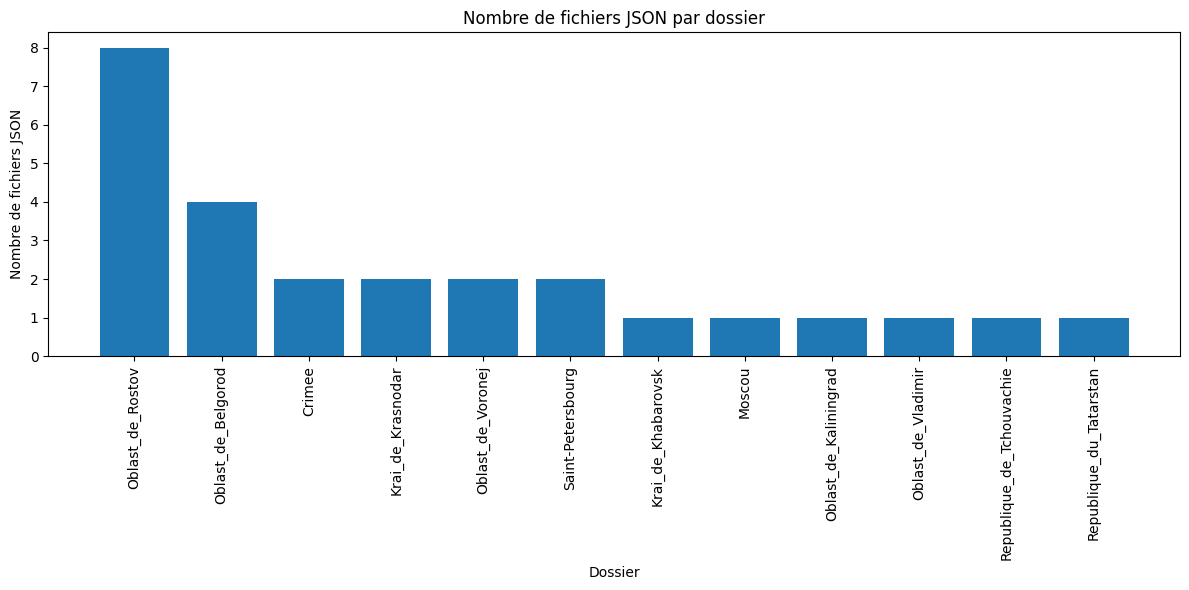

In [33]:
#1. Quels regions sont présentent dans le corpus ?
#2. Combien de l'espaces de communication (chats) pour chaque région ?

subfolders = sorted([p for p in ROOT_FOLDER.iterdir() if p.is_dir()], key=lambda x: x.name.lower())

stats = []
for folder in subfolders:
    json_count = len(list(folder.glob("*.json")))
    stats.append((folder.name, json_count))

stats = sorted(stats, key=lambda x: x[1], reverse=True)


print("Statistique : nombre de fichiers JSON par dossier\n")
total_files = 0
for folder_name, count in stats:
    print(f"{folder_name}: {count}")
    total_files += count

print(f"\nTotal de fichiers JSON: {total_files}")
print(f"Nombre de dossiers: {len(stats)}")

# Гистограмма

folder_names = [x[0] for x in stats]
file_counts = [x[1] for x in stats]

plt.figure(figsize=(12, 6))
plt.bar(folder_names, file_counts)
plt.xticks(rotation=90)
plt.ylabel("Nombre de fichiers JSON")
plt.xlabel("Dossier")
plt.title("Nombre de fichiers JSON par dossier")
plt.tight_layout()
plt.show()


Statistique : nombre de messages par fichier et somme par dossier

Oblast_de_Rostov:
  le_bienfait_a_taganrog.json - 5713
  dobrovolets_de_leningrad.json - 4627
  les_gens_pas_indifferents.json - 4482
  murmure_du_benevole.json - 2204
  centre_aide_humanitaire_misericorde_du_don.json - 1464
  fondation_caritative_une_bonne_action.json - 1428
  chers_invites_de_taganrog.json - 1143
  aide_humanitaire_dans_la_region_de_rostov.json - 678
  SOMME: 21739

Oblast_de_Belgorod:
  confrerie_de_la_charite.json - 7190
  interaction.json - 3774
  armiya_krasotok.json - 1779
  etre_plus_bienveillant.json - 138
  SOMME: 12881

Crimee:
  benevoles_crimee.json - 11682
  bienfait_kerch.json - 1161
  SOMME: 12843

Oblast_de_Vladimir:
  benevole_sidorova.json - 8249
  SOMME: 8249

Moscou:
  dari_edu.json - 6039
  SOMME: 6039

Krai_de_Krasnodar:
  ben_krasnodar.json - 1718
  aimez_proche.json - 395
  SOMME: 2113

Oblast_de_Voronej:
  lart_de_vivre.json - 1438
  corps_de_volontaire.json - 547
  SOMME: 1985

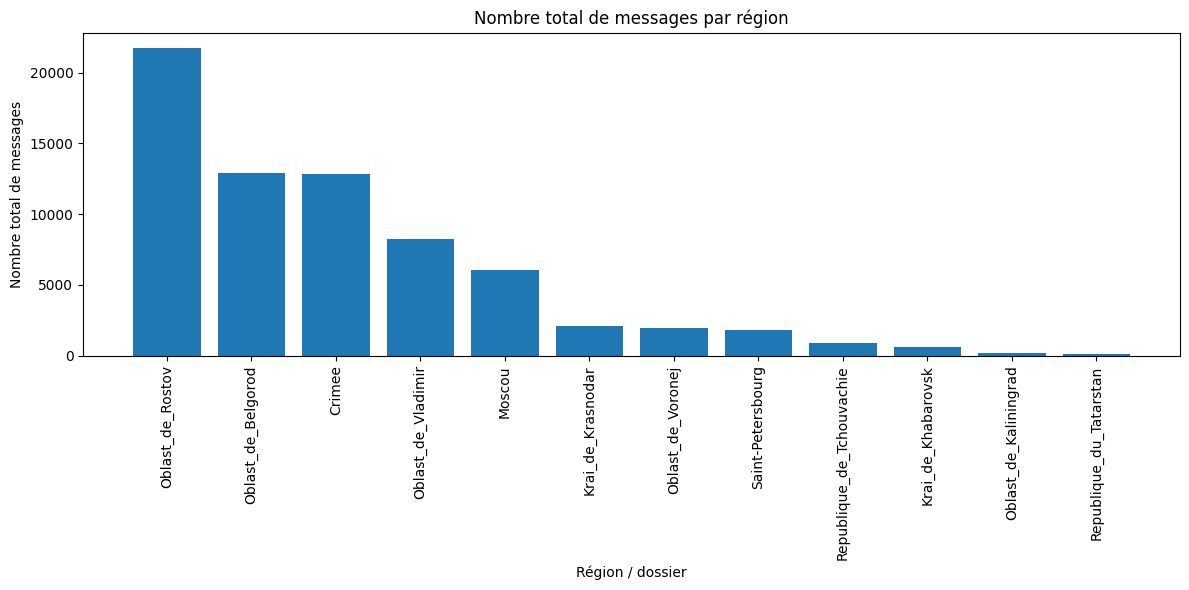

In [34]:
def extract_entries(obj):
    if isinstance(obj, list):
        return obj

    if isinstance(obj, dict):
        preferred_keys = ["messages", "entries", "items", "results", "data"]
        for key in preferred_keys:
            if key in obj:
                value = obj[key]
                if isinstance(value, list):
                    return value
                if isinstance(value, dict):
                    nested = extract_entries(value)
                    if nested is not None:
                        return nested

        for value in obj.values():
            nested = extract_entries(value)
            if nested is not None:
                return nested

    return None

def count_entries_in_json(json_path):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        entries = extract_entries(data)
        return len(entries) if entries is not None else 0
    except Exception as e:
        print(f"Erreur avec {json_path.name}: {e}")
        return 0

subfolders = sorted(
    [p for p in ROOT_FOLDER.iterdir() if p.is_dir()],
    key=lambda x: x.name.lower()
)

folder_reports = []
grand_total_entries = 0

for folder in subfolders:
    json_files = sorted(folder.glob("*.json"), key=lambda x: x.name.lower())

    file_stats = []
    total_entries_in_folder = 0

    for json_file in json_files:
        count = count_entries_in_json(json_file)
        file_stats.append((json_file.name, count))
        total_entries_in_folder += count

    # сортировка файлов внутри папки по числу сообщений
    file_stats = sorted(file_stats, key=lambda x: x[1], reverse=True)

    folder_reports.append({
        "folder_name": folder.name,
        "file_stats": file_stats,
        "folder_sum": total_entries_in_folder
    })

    grand_total_entries += total_entries_in_folder

# сортировка папок по сумме
folder_reports = sorted(folder_reports, key=lambda x: x["folder_sum"], reverse=True)

print("Statistique : nombre de messages par fichier et somme par dossier\n")

for report in folder_reports:
    print(f'{report["folder_name"]}:')
    for file_name, count in report["file_stats"]:
        print(f"  {file_name} - {count}")
    print(f'  SOMME: {report["folder_sum"]}\n')

print("Résumé général")
for report in folder_reports:
    print(f'{report["folder_name"]}: {report["folder_sum"]}')

print(f"\nTotal général d'entries: {grand_total_entries}")
print(f"Nombre de dossiers: {len(folder_reports)}")

# Гистограмма по суммам папок
folder_names = [report["folder_name"] for report in folder_reports]
entry_counts = [report["folder_sum"] for report in folder_reports]

plt.figure(figsize=(12, 6))
plt.bar(folder_names, entry_counts)
plt.xticks(rotation=90)
plt.ylabel("Nombre total de messages")
plt.xlabel("Région / dossier")
plt.title("Nombre total de messages par région")
plt.tight_layout()
plt.show()

In [35]:
# Quand est ce que ces chats étaient actifs ? (premier et dernier message)

def first_last_message_dates(json_path):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data["messages"]

        dates = []
        for message in messages:
            if "date" in message and message["date"]:
                dt = pd.to_datetime(message["date"], errors="coerce")
                if pd.notna(dt):
                    dates.append(dt)

        if not dates:
            return None, None

        return min(dates), max(dates)

    except Exception as e:
        print(f"Erreur avec {json_path.name}: {e}")
        return None, None


subfolders = sorted(
    [p for p in ROOT_FOLDER.iterdir() if p.is_dir()],
    key=lambda x: x.name.lower()
)

print("Statistique : première et dernière date de message par fichier\n")

total_folders = 0
total_files = 0
files_with_dates = 0

for folder in subfolders:
    json_files = sorted(folder.glob("*.json"), key=lambda x: x.name.lower())
    if not json_files:
        continue

    total_folders += 1
    total_files += len(json_files)

    print(f"{folder.name}:")
    max_len = max(len(jf.name) for jf in json_files)

    for json_file in json_files:
        first_dt, last_dt = first_last_message_dates(json_file)

        if first_dt is not None and last_dt is not None:
            files_with_dates += 1
            first_str = first_dt.strftime("%Y-%m-%d %H:%M:%S")
            last_str = last_dt.strftime("%Y-%m-%d %H:%M:%S")
        else:
            first_str = "date non trouvée"
            last_str = "date non trouvée"

        print(
            f"    {json_file.name:<{max_len}}    "
            f"premier message: {first_str}    "
            f"dernier message: {last_str}"
        )

    print()

print("Résumé")
print(f"    Dossiers analysés: {total_folders}")
print(f"    Fichiers analysés: {total_files}")
print(f"    Fichiers avec dates trouvées: {files_with_dates}")
print(f"    Fichiers sans dates trouvées: {total_files - files_with_dates}")

Statistique : première et dernière date de message par fichier

Crimee:
    benevoles_crimee.json    premier message: 2022-02-26 11:21:36    dernier message: 2025-11-12 16:02:40
    bienfait_kerch.json      premier message: 2022-03-11 16:48:22    dernier message: 2025-07-25 19:01:20

Krai_de_Khabarovsk:
    assistance_khabarovsk.json    premier message: 2022-05-05 05:59:01    dernier message: 2023-09-13 11:34:22

Krai_de_Krasnodar:
    aimez_proche.json     premier message: 2022-05-17 06:32:41    dernier message: 2022-08-17 19:06:01
    ben_krasnodar.json    premier message: 2022-04-02 00:52:45    dernier message: 2025-04-02 18:12:41

Moscou:
    dari_edu.json    premier message: 2022-02-25 17:25:59    dernier message: 2025-11-12 12:17:03

Oblast_de_Belgorod:
    armiya_krasotok.json            premier message: 2022-03-05 11:35:06    dernier message: 2023-05-14 16:00:21
    confrerie_de_la_charite.json    premier message: 2022-03-24 11:48:29    dernier message: 2025-11-12 14:39:13
    

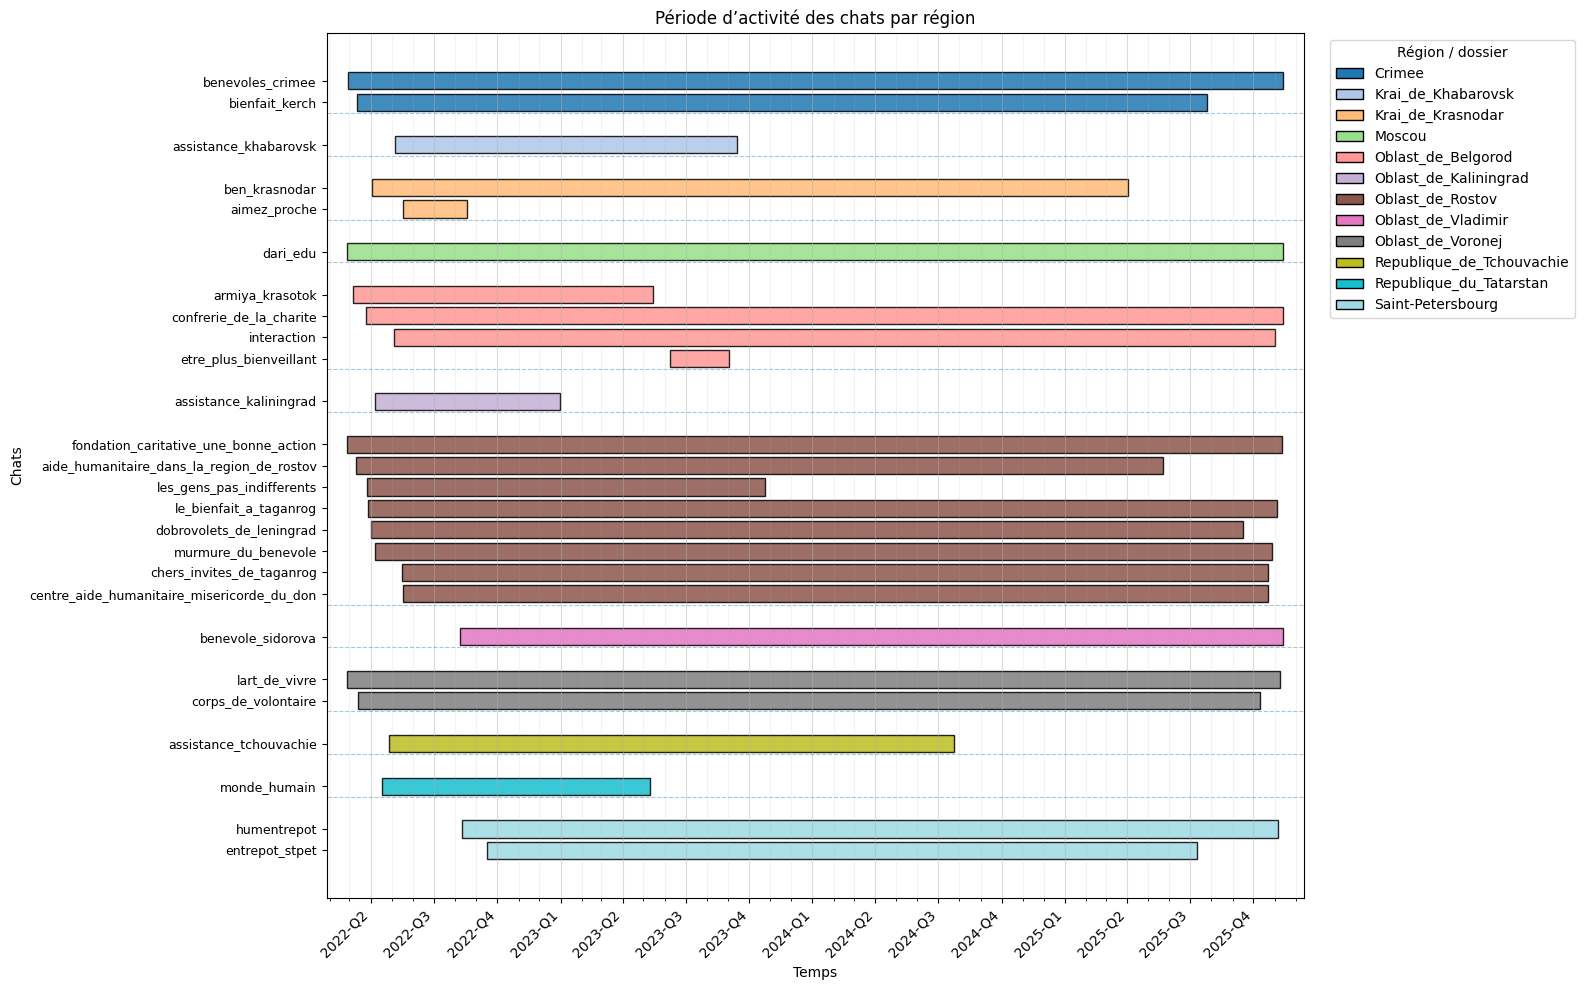

In [36]:
# Visualisation de la période d’activité des chats par région

import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

folder_data = []

for folder in subfolders:
    json_files = sorted(folder.glob("*.json"), key=lambda x: x.name.lower())
    chats = []

    for json_file in json_files:
        first_dt, last_dt = first_last_message_dates(json_file)

        if first_dt is not None and last_dt is not None:
            chats.append({
                "chat_name": json_file.stem,
                "start": first_dt,
                "end": last_dt
            })

    chats = sorted(chats, key=lambda x: x["start"])

    if chats:
        folder_data.append({
            "folder_name": folder.name,
            "chats": chats
        })

if not folder_data:
    print("Aucune donnée temporelle trouvée.")
else:
    cmap = plt.get_cmap("tab20", len(folder_data))
    folder_colors = {
        folder_data[i]["folder_name"]: cmap(i)
        for i in range(len(folder_data))
    }

    fig, ax = plt.subplots(figsize=(16, 10))

    y_positions = []
    y_labels = []
    group_separators = []

    current_y = 0
    all_starts = []
    all_ends = []

    for folder_item in folder_data:
        folder_name = folder_item["folder_name"]
        chats = folder_item["chats"]

        for chat in chats:
            start_num = mdates.date2num(chat["start"])
            end_num = mdates.date2num(chat["end"])

            ax.barh(
                y=current_y,
                width=end_num - start_num,
                left=start_num,
                height=0.8,
                color=folder_colors[folder_name],
                edgecolor="black",
                alpha=0.85
            )

            y_positions.append(current_y)
            y_labels.append(chat["chat_name"])
            all_starts.append(chat["start"])
            all_ends.append(chat["end"])

            current_y += 1

        group_separators.append(current_y - 0.5)
        current_y += 1  # espace entre dossiers

    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=9)

    global_start = min(all_starts)
    global_end = max(all_ends)
    pad = pd.Timedelta(days=30)
    ax.set_xlim(global_start - pad, global_end + pad)

    # Axe X : ticks principaux par trimestre, ticks secondaires par mois
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    def quarter_formatter(x, pos):
        dt = mdates.num2date(x)
        quarter = (dt.month - 1) // 3 + 1
        return f"{dt.year}-Q{quarter}"

    ax.xaxis.set_major_formatter(FuncFormatter(quarter_formatter))

    # séparateurs entre régions
    for sep in group_separators[:-1]:
        ax.axhline(sep, linestyle="--", linewidth=0.8, alpha=0.4)

    legend_elements = [
        Patch(facecolor=folder_colors[name], edgecolor="black", label=name)
        for name in folder_colors
    ]
    ax.legend(
        handles=legend_elements,
        title="Région / dossier",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.set_xlabel("Temps")
    ax.set_ylabel("Chats")
    ax.set_title("Période d’activité des chats par région")

    # Сетка: кварталы и месяцы
    ax.grid(axis="x", which="major", alpha=0.45)
    ax.grid(axis="x", which="minor", alpha=0.15)

    ax.invert_yaxis()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 2. Nettoyage et préparation des données

Cette partie transforme les exports Telegram bruts en un corpus exploitable pour l’analyse textuelle. Les fichiers Telegram contiennent de nombreux éléments qui ne relèvent pas directement du contenu discursif : messages de service, médias, stickers, liens, mentions, doublons, messages très courts ou vides.

Le nettoyage vise donc à reconstruire un champ textuel homogène, à supprimer les éléments non pertinents et à conserver une trace des opérations effectuées grâce à des fichiers de statistiques.

### 2.1. Préparation technique

Cette cellule importe les bibliothèques nécessaires au nettoyage : comptage des types d’éléments, gestion des fichiers JSON, tirage d’exemples aléatoires, parcours des dossiers et suivi de la progression.

In [5]:
from collections import Counter
from collections import defaultdict
import random
from typing import List, Dict, Any
from pathlib import Path
import json
from tqdm.auto import tqdm

### 2.2. Structure des exports Telegram

Avant le nettoyage, le notebook inspecte la structure interne d’un fichier JSON Telegram. L’objectif est d’identifier les champs disponibles dans les messages et de comprendre comment le texte est stocké, notamment dans les champs `text` et `text_entities`.

In [58]:
with open("/Users/quentinnippert/Documents/mm_files/Telegram_analyse/activites_benevoles/Crimee/benevoles_crimee.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(data.keys())


dict_keys(['name', 'type', 'id', 'messages'])


In [59]:
all_keys = set().union(*(msg.keys() for msg in data["messages"]))
print(all_keys)

{'file_size', 'photo_file_size', 'forwarded_from', 'text_entities', 'actor', 'duration_seconds', 'id', 'from_id', 'media_type', 'action', 'file', 'type', 'from', 'title', 'text', 'photo', 'file_name', 'height', 'reactions', 'performer', 'thumbnail', 'mime_type', 'date', 'actor_id', 'width', 'date_unixtime', 'forwarded_from_id', 'edited', 'thumbnail_file_size', 'edited_unixtime', 'message_id'}


#### Description des principales clés des messages Telegram

Les exports Telegram associent aux messages un grand nombre de métadonnées : identifiants, dates, auteurs, médias, entités textuelles, actions de service, etc. Cette étape permet de distinguer les informations utiles pour l’analyse textuelle des champs à ignorer lors du nettoyage.

Le champ le plus important pour la reconstruction du texte est `text_entities`, car il permet de récupérer uniquement les segments textuels pertinents en excluant certaines entités techniques ou moins utiles pour l’analyse.

In [ ]:
entity_types = Counter()

for msg in data.get("messages", []):
    ents = msg.get("text_entities")
    if isinstance(ents, list):
        for e in ents:
            if isinstance(e, dict) and "type" in e:
                entity_types[e["type"]] += 1

print("Типы text_entities и их количество :\n")
for t, c in entity_types.most_common():
    print(f"{t:15} {c}")

Типы text_entities и их количество :

plain           19225
hashtag         10742
link            1484
text_link       890
phone           790
code            367
mention         347
bold            277
bank_card       210
email           54
italic          13
underline       12
blockquote      12
custom_emoji    11
strikethrough   2
mention_name    2


In [ ]:
#exemples pour chaque type d'entité


examples_by_type = defaultdict(list)

for msg in data.get("messages", []):
    ents = msg.get("text_entities")
    if isinstance(ents, list):
        for e in ents:
            if isinstance(e, dict):
                t = e.get("type")
                txt = e.get("text")
                if isinstance(t, str) and isinstance(txt, str):
                    if len(examples_by_type[t]) < 2:
                        examples_by_type[t].append(txt.strip())

print("Exemples extraits de text_entities :\n")
for t, ex_list in examples_by_type.items():
    print(f"--- {t} ---")
    for i, ex in enumerate(ex_list, 1):
        print(f"{i}. {ex[:120]}")
    print()

Exemples extraits de text_entities :

--- plain ---
1. Гуманитарная помощь на границу для беженцев, которые едут в Крым попала в сюжет новостей. Ситуация сложная, продолжаем п
2. ❗️Несколько тысяч жителей Украины за 4 дня пересекли границу с Россией в пунктах пропуска на севере Крыма. Люди бегут на

--- link ---
1. https://vk.com/topic-9151329_34209566
2. https://trkmillet.ru/program-episode/tok-shou-tak-ili-inache-vremya-pomogat/

--- bank_card ---
1. 2200020222048425
2. 2200020222048425

--- phone ---
1. +79787021010
2. +79787353853

--- hashtag ---
1. #ЗдоровоеДетствоКрым
2. #ДоброМираВолонтерыКрыма

--- mention ---
1. @drygoedelo
2. @iuliannastakhno

--- text_link ---
1. Джанкой в  объективе
2. https://youtu.be/bi9DU0_N4TE

--- email ---
1. office@krym-ms.ru
2. krymbumaga@mail.ru

--- bold ---
1. В Крыму вынужденным переселенцам оказывают полномасштабную помощь
2. Жителей Симферополя приглашают на диспансеризацию

--- italic ---
1. возрасте до 40 лет
2. на один рабочий день раз в т

In [ ]:
#Messages sans du tout de text_entities sont les messages vides 

# Собираем все сообщения без text_entities
no_entities = [
    msg for msg in data.get("messages", [])
    if not msg.get("text_entities")
]

print(f" {len(no_entities)} Trouvé sans text_entities.\n")

# Если меньше 5, показываем все; иначе случайные 5
sample_msgs = random.sample(no_entities, min(5, len(no_entities)))

for i, msg in enumerate(sample_msgs, 1):
    print(f"=== Message aléatoire {i} ===")
    print(json.dumps(msg, ensure_ascii=False, indent=2))
    print("=" * 100)


 6918 Trouvé sans text_entities.

=== Message aléatoire 1 ===
{
  "id": 8904,
  "type": "message",
  "date": "2024-10-10T17:01:40",
  "date_unixtime": "1728572500",
  "from": "Добро Мира - Волонтёры Крыма",
  "from_id": "channel1788719158",
  "photo": "(File not included. Change data exporting settings to download.)",
  "photo_file_size": 64582,
  "width": 1280,
  "height": 853,
  "text": "",
  "text_entities": []
}
=== Message aléatoire 2 ===
{
  "id": 4031,
  "type": "message",
  "date": "2023-05-19T08:01:55",
  "date_unixtime": "1684476115",
  "edited": "2023-05-19T08:03:09",
  "edited_unixtime": "1684476189",
  "from": "Добро Мира - Волонтёры Крыма",
  "from_id": "channel1788719158",
  "file": "(File not included. Change data exporting settings to download.)",
  "file_name": "IMG_3494.MP4",
  "file_size": 17861478,
  "thumbnail": "(File not included. Change data exporting settings to download.)",
  "thumbnail_file_size": 18881,
  "media_type": "video_file",
  "mime_type": "video/mp

In [45]:
#Est ce qu'on peut prendre les types_entities "plain", "bold", "italic", "underline", "spoiler", "pre", "blockquote" et comme ca rétirer l'information inutile pour nous dans les texts des messages ? 

#Exemple : 


# Types de text_entities à inclure dans l'extraction/affichage
ALLOWED_TYPES = {"plain", "bold", "italic", "underline", "spoiler", "pre", "blockquote"}

def flatten_text_field(t) -> str:
    """
    Renvoie le texte lisible à partir du champ 'text'.
    - si c’est une chaîne → renvoie directement
    - si c’est une liste → concatène les éléments (en prenant 'text' dans les dictionnaires)
    """
    if isinstance(t, str):
        return t
    if isinstance(t, list):
        parts = []
        for el in t:
            if isinstance(el, str):
                parts.append(el)
            elif isinstance(el, dict) and isinstance(el.get("text"), str):
                parts.append(el["text"])
        return "".join(parts)
    return ""

def collect_entities_text(msg: Dict[str, Any]) -> str:
    """
    Récupère le texte uniquement des 'text_entities' dont le type est
    dans ALLOWED_TYPES et les fusionne dans une seule chaîne.
    """
    ents = msg.get("text_entities")
    if not isinstance(ents, list) or not ents:
        return ""
    raw_text = msg.get("text")
    raw_text_str = raw_text if isinstance(raw_text, str) else None

    picked: List[str] = []
    for e in ents:
        if not isinstance(e, dict):
            continue
        etype = e.get("type")
        if etype not in ALLOWED_TYPES:
            continue

        if isinstance(e.get("text"), str):
            picked.append(e["text"])
        elif raw_text_str is not None:
            off = e.get("offset")
            ln = e.get("length")
            if isinstance(off, int) and isinstance(ln, int) and off >= 0 and ln >= 0:
                frag = raw_text_str[off:off+ln]
                if frag:
                    picked.append(frag)

    return "".join(picked).strip()

# =======================================
#  Sélection de messages selon le critère mixte
#  (≥1 entité d'un type autorisé ET ≥1 entité d'un type non autorisé)
# =======================================
def sample_mixed_entity_messages(data: Dict[str, Any], n: int = 5):
    messages = data.get("messages", data)
    if not isinstance(messages, list):
        raise ValueError("On attendait une liste dans data['messages'].")

    selected = []
    for msg in messages:
        ents = msg.get("text_entities")
        if not isinstance(ents, list) or not ents:
            continue

        types_in_msg = {e.get("type") for e in ents if isinstance(e, dict) and isinstance(e.get("type"), str)}
        if not types_in_msg:
            continue

        has_allowed = any(t in ALLOWED_TYPES for t in types_in_msg)
        has_other = any((t not in ALLOWED_TYPES) for t in types_in_msg)

        # On ne garde que les messages qui ont au moins un type autorisé ET au moins un autre type
        if has_allowed and has_other:
            selected.append(msg)

    if not selected:
        print("Aucun message ne contient à la fois une entité autorisée et une entité non autorisée.")
        return

    k = min(n, len(selected))
    for i, msg in enumerate(random.sample(selected, k), 1):
        mid = msg.get("id")
        mdate = msg.get("date")
        mfrom = msg.get("from")
        full_text = flatten_text_field(msg.get("text", ""))
        ents_text = collect_entities_text(msg)

        print(f"\n=== Message {i} / id={mid} / date={mdate} / auteur={mfrom} ===\n")
        print("Texte du message :")
        print(full_text if full_text else "(vide)")

        print("\nTexte issu de 'text_entities' (plain/bold/italic/underline/spoiler/pre/blockquote) :")
        print(ents_text if ents_text else "(aucune entité correspondante)")

        print("\nContenu complet du message (JSON) :")
        print(json.dumps(msg, ensure_ascii=False, indent=2))
        print("=" * 120)


In [69]:
sample_mixed_entity_messages(data, n=5)


=== Message 1 / id=10206 / date=2025-03-07T07:02:16 / auteur=Добро Мира - Волонтёры Крыма ===

Texte du message :
#ЗдоровоеДетствоКрым 

Знакомьтесь, это Настя ☀️

Сразу после рождения малышка попала в реанимацию.. Далее последовали бесконечные обследования и поиск компетентных врачей. Окончательный диагноз вверг родителей в состояние шока: эпилепсия ДЦП и умственная отсталость.. Но сдаваться семья не собиралась - началась жесточайшая борьба за подбор верной терапии, адаптацию и развитие девочки, которая каждый год демонстрирует  невероятные успехи: обучение навыкам, преодоление физических ограничений, формирование общения. К сожалению, реабилитация, столь необходимая для новых побед над болезнью, стоит очень больших денег,  а ресурсы родителей давно исчерпаны.. Очень просим всех неравнодушных помочь Настеньке сделать дальнейшие  шаги  как в физическом, так и в умственном развитии🙏🏻

✨Помочь особенным деткам можно по любым официальным реквизитам добра: vk.com/topic-9151329_34209566 
К

### 2.3. Reconstruction du texte des messages

Le texte des messages est reconstruit à partir de certains types d’entités seulement : `plain`, `bold`, `italic`, `underline`, `spoiler`, `pre` et `blockquote`. Cette sélection permet de conserver le contenu textuel lisible tout en évitant de surreprésenter des éléments techniques comme les liens, mentions ou objets multimédias.

Le texte reconstruit est enregistré dans un nouveau champ `text_clean`, qui servira ensuite aux étapes de filtrage, de lemmatisation et de visualisation.

#### Application de la reconstruction textuelle à l’ensemble des fichiers

La même procédure est appliquée aux deux dossiers de travail. Pour chaque message, un champ `text_clean` est créé ou remplacé. Ce champ devient la version standardisée du texte utilisée dans toutes les étapes suivantes.

In [60]:
ROOT_FOLDERS = [Path("chats"), Path("activites_benevoles")]

json_files = []
for root_folder in ROOT_FOLDERS:
    if root_folder.exists():
        json_files.extend(sorted(root_folder.rglob("*.json"), key=lambda x: str(x).lower()))
    else:
        print(f"Dossier non trouvé: {root_folder}")

In [61]:
# Cette cellule suppose que ces objets/fonctions sont déjà définis :
# - ALLOWED_TYPES
# - flatten_text_field
# - collect_entities_text

processed_files = 0
processed_messages = 0

for json_path in tqdm(json_files, desc="Traitement des fichiers JSON"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data.get("messages")
        if not isinstance(messages, list):
            continue

        for msg in messages:
            if not isinstance(msg, dict):
                continue

            # Texte reconstruit uniquement à partir des text_entities autorisées
            text_clean = collect_entities_text(msg)

            # Fallback minimal : si aucune text_entity n'est présente
            # et que le champ text est déjà une chaîne simple, on la garde.
            if not text_clean and isinstance(msg.get("text"), str):
                text_clean = msg["text"].strip()

            msg["text_clean"] = text_clean
            processed_messages += 1

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

        processed_files += 1

    except Exception as e:
        print(f"Erreur avec {json_path}: {e}")

print(f"\nTerminé.")
print(f"Fichiers traités : {processed_files}")
print(f"Messages traités : {processed_messages}")

Traitement des fichiers JSON:   0%|          | 0/67 [00:00<?, ?it/s]


Terminé.
Fichiers traités : 67
Messages traités : 1688614


#### Suppression des messages vides

Une fois le champ `text_clean` créé, les messages sans texte exploitable sont supprimés. Cela concerne notamment les messages purement multimédias, les messages de service ou les entrées dont le contenu textuel n’a pas pu être reconstruit.

In [62]:
stats = []
total_before = 0
total_after = 0

for json_path in tqdm(json_files, desc="Suppression des messages vides"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data.get("messages")
        if not isinstance(messages, list):
            continue

        before_count = len(messages)

        filtered_messages = []
        for msg in messages:
            if not isinstance(msg, dict):
                continue

            text_clean = msg.get("text_clean", "")
            if isinstance(text_clean, str) and text_clean.strip():
                filtered_messages.append(msg)

        after_count = len(filtered_messages)

        data["messages"] = filtered_messages

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

        region = json_path.parent.name
        stats.append({
            "region": region,
            "file_name": json_path.name,
            "before": before_count,
            "after": after_count
        })

        total_before += before_count
        total_after += after_count

    except Exception as e:
        print(f"Erreur avec {json_path}: {e}")

print("\nStatistique par région et fichier\n")

for row in sorted(stats, key=lambda x: (x["region"].lower(), x["file_name"].lower())):
    print(f'{row["region"]} | {row["file_name"]} - avant: {row["before"]}, après: {row["after"]}')

print("\nRésumé général")
print(f"Messages avant: {total_before}")
print(f"Messages après: {total_after}")
print(f"Messages supprimés: {total_before - total_after}")

Suppression des messages vides:   0%|          | 0/67 [00:00<?, ?it/s]


Statistique par région et fichier

Crimee | benevoles_crimee.json - avant: 11682, après: 4730
Crimee | bienfait_kerch.json - avant: 1161, après: 443
Crimee | cher_crimee.json - avant: 4219, après: 2832
Crimee | refugees_crimee.json - avant: 66302, après: 51425
Crimee | refugees_sevastopol.json - avant: 38250, après: 31969
Crimee | refugees_simpheropol.json - avant: 55191, après: 44895
Krai_de_Khabarovsk | assistance_khabarovsk.json - avant: 606, après: 536
Krai_de_Krasnodar | aimez_proche.json - avant: 395, après: 92
Krai_de_Krasnodar | assistance_krasnodar.json - avant: 13231, après: 8763
Krai_de_Krasnodar | assistance_novorossiysk.json - avant: 28940, après: 23795
Krai_de_Krasnodar | assistance_sotchi.json - avant: 938, après: 810
Krai_de_Krasnodar | assistance_tuapse.json - avant: 38157, après: 33487
Krai_de_Krasnodar | ben_krasnodar.json - avant: 1718, après: 762
Krai_de_Krasnodar | centre_krasnodar.json - avant: 11208, après: 9227
Krai_de_Krasnodar | habitants_krasnodar.json - av

In [63]:
with open("stats_nettoyage/stats_1_suppression_vides.json", "w", encoding="utf-8") as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

### 2.4. Suppression des doublons

Les exports Telegram contiennent de nombreux messages répétés. Il peut s’agir de rappels d’information, de messages publicitaires, de consignes repostées dans plusieurs espaces ou de réponses très courtes répétées plusieurs fois.

Cette étape supprime les doublons à partir du champ `text_clean`, tout en sauvegardant les messages retirés dans des dossiers séparés. Cela permet de nettoyer le corpus principal sans perdre complètement la possibilité d’examiner les répétitions.

In [88]:
#Check an exemple 

json_path = Path("/Users/quentinnippert/Documents/mm_files/Telegram_analyse/2activites_benevoles_msgcleannonvide/Oblast_de_Rostov/aide_humanitaire_dans_la_region_de_rostov.json")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

messages = data.get("messages", [])

groups = defaultdict(list)

for msg in messages:
    if not isinstance(msg, dict):
        continue

    text_clean = msg.get("text_clean")
    if not isinstance(text_clean, str):
        continue

    key = text_clean.strip()
    if not key:
        continue

    groups[key].append(msg)

duplicate_groups = [(text, msgs) for text, msgs in groups.items() if len(msgs) > 1]

if not duplicate_groups:
    print("No doublons trouvés dans les messages de ce fichier.")
else:
    dup_text, dup_msgs = random.choice(duplicate_groups)

    print(f"Fichier: {json_path.name}")
    print(f"Nombre de doublons trouvés: {len(dup_msgs)}\n")

    print("Exemple de text_clean répétitif:\n")
    print(dup_text)

    print("\nMétadonnées des doublons:\n")
    for i, msg in enumerate(dup_msgs, start=1):
        author = msg.get("from") or msg.get("actor")
        print(f"{i}. id={msg.get('id')} | date={msg.get('date')} | auteur={author}")

Fichier: aide_humanitaire_dans_la_region_de_rostov.json
Nombre de doublons trouvés: 2

Exemple de text_clean répétitif:

Дорогие друзья!
💖От всего сердца благодарим всех неравнодушных жителей Ростовской области, других регионов России и за оказанную помощь и поддержку жителям Донбасса и Украины!

Наш пункт приема/выдачи гуманитарной помощи в г. Ростове-на-Дону общественного движения "Добро-на-Дону" продолжает принимать от физических и юридических лиц благотворительную помощь в виде:

- детской и взрослой одежды и обуви (всех сезонов);
- детского питания и смесей;
- детских памперсов всех размеров (в т.ч. 4-5р.);
- средств гигиены (памперсы для взрослых, пеленки, салфетки, зубная паста, зубные щетки и др.);
- средств бытовой химии (стиральный порошок, чистящие и дезинфицирующие средства);
- детских игрушек и книг;
- постельного белья, подушек, одеял, полотенец;
- посуды;
- лекарственных препаратов и медикаментов, перевязочных материалов;
- канцелярских товаров, школьных форм и рюкзаков 

Les doublons sont retirés du corpus principal, mais conservés dans des fichiers séparés. Cette stratégie permet de réduire le bruit pour les analyses textuelles tout en gardant une trace des phénomènes de répétition, qui peuvent eux-mêmes être significatifs dans les espaces d’entraide.

In [64]:

stats = []
total_before = 0
total_after = 0
total_duplicates_removed = 0

for json_path in tqdm(json_files, desc="Suppression des doublons"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data.get("messages")
        if not isinstance(messages, list):
            continue

        kept_messages = []
        duplicate_messages = []
        seen_texts = set()

        for msg in messages:
            if not isinstance(msg, dict):
                continue

            text_clean = msg.get("text_clean")
            if not isinstance(text_clean, str):
                kept_messages.append(msg)
                continue

            key = text_clean.strip()

            # пустые text_clean уже должны были быть удалены раньше,
            # но на всякий случай такие сообщения оставляем
            if not key:
                kept_messages.append(msg)
                continue

            if key in seen_texts:
                duplicate_messages.append(msg)
            else:
                seen_texts.add(key)
                kept_messages.append(msg)

        before_count = len(messages)
        after_count = len(kept_messages)
        removed_count = len(duplicate_messages)

        # Перезаписываем оригинальный файл без дублей
        data["messages"] = kept_messages
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

        # Если были дубли, сохраняем их в отдельный файл с той же структурой папок
        if removed_count > 0:
            corpus_root = json_path.parts[0]  # chats / activites_benevoles
            dup_root = Path(f"{corpus_root}_duplicates")
            relative_path = json_path.relative_to(corpus_root)
            dup_json_path = dup_root / relative_path
            dup_json_path.parent.mkdir(parents=True, exist_ok=True)

            dup_data = dict(data)
            dup_data["messages"] = duplicate_messages

            with open(dup_json_path, "w", encoding="utf-8") as f:
                json.dump(dup_data, f, ensure_ascii=False, indent=2)

        stats.append({
            "corpus": json_path.parts[0],
            "region": json_path.parent.name,
            "file_name": json_path.name,
            "before": before_count,
            "after": after_count,
            "duplicates_removed": removed_count
        })

        total_before += before_count
        total_after += after_count
        total_duplicates_removed += removed_count

    except Exception as e:
        print(f"Erreur avec {json_path}: {e}")

print("\nStatistique par fichier\n")

for row in sorted(stats, key=lambda x: (x["corpus"].lower(), x["region"].lower(), x["file_name"].lower())):
    print(
        f'{row["corpus"]} | {row["region"]} | {row["file_name"]} '
        f'- avant: {row["before"]}, après: {row["after"]}, doublons supprimés: {row["duplicates_removed"]}'
    )

print("\nRésumé général")
print(f"Messages avant: {total_before}")
print(f"Messages après: {total_after}")
print(f"Doublons supprimés: {total_duplicates_removed}")
print(f"Dossiers créés: chats_duplicates / activites_benevoles_duplicates")

Suppression des doublons:   0%|          | 0/67 [00:00<?, ?it/s]


Statistique par fichier

activites_benevoles | Crimee | benevoles_crimee.json - avant: 4730, après: 4632, doublons supprimés: 98
activites_benevoles | Crimee | bienfait_kerch.json - avant: 443, après: 442, doublons supprimés: 1
activites_benevoles | Crimee | cher_crimee.json - avant: 2832, après: 2747, doublons supprimés: 85
activites_benevoles | Krai_de_Khabarovsk | assistance_khabarovsk.json - avant: 536, après: 536, doublons supprimés: 0
activites_benevoles | Krai_de_Krasnodar | aimez_proche.json - avant: 92, après: 92, doublons supprimés: 0
activites_benevoles | Krai_de_Krasnodar | ben_krasnodar.json - avant: 762, après: 760, doublons supprimés: 2
activites_benevoles | Krai_de_Krasnodar | centre_krasnodar.json - avant: 9227, après: 8607, doublons supprimés: 620
activites_benevoles | Moscou | dari_edu.json - avant: 1524, après: 1524, doublons supprimés: 0
activites_benevoles | Oblast_de_Belgorod | a_tes_cotes.json - avant: 15266, après: 13153, doublons supprimés: 2113
activites_ben

In [65]:
#sauvegarder les stats

with open("stats_nettoyage/stats_2_suppression_doublons.json", "w", encoding="utf-8") as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

### 2.5. Création de blocs de messages

Dans les chats Telegram, une même personne envoie souvent plusieurs messages courts à la suite. Pour mieux représenter la continuité de l’intervention, ces messages successifs sont fusionnés en un seul bloc lorsque le même auteur écrit plusieurs messages rapprochés dans le temps.

Cette opération est appliquée uniquement aux chats de discussion, et non aux espaces d’activité bénévole. Elle permet de travailler sur des unités discursives plus proches d’une prise de parole complète.

In [66]:
ROOT_FOLDER = Path("chats")

json_files = []
if ROOT_FOLDER.exists():
    json_files = sorted(ROOT_FOLDER.rglob("*.json"), key=lambda x: str(x).lower())
else:
    print(f"Dossier non trouvé: {ROOT_FOLDER}")

TIME_GAP_MINUTES = 10

In [67]:
# fusion selon 'from_id' dans le dossier chats uniquement
from copy import deepcopy

stats = []
total_before = 0
total_after = 0

for json_path in tqdm(json_files, desc="Création des message blocks"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data.get("messages")
        if not isinstance(messages, list) or not messages:
            continue

        merged_messages = []
        current_block = None

        for msg in messages:
            if not isinstance(msg, dict):
                continue

            text_clean = msg.get("text_clean", "")
            if not isinstance(text_clean, str) or not text_clean.strip():
                continue

            current_from_id = msg.get("from_id")
            current_date = pd.to_datetime(msg.get("date"), errors="coerce")

            if current_block is None:
                current_block = deepcopy(msg)
                current_block["text_clean"] = text_clean.strip()
                current_block["block_start"] = msg.get("date")
                current_block["block_end"] = msg.get("date")
                current_block["merged_message_count"] = 1
                current_block["merged_message_ids"] = [msg.get("id")]
                continue

            previous_from_id = current_block.get("from_id")
            previous_date = pd.to_datetime(current_block.get("block_end"), errors="coerce")

            within_time_gap = False
            if pd.notna(current_date) and pd.notna(previous_date):
                gap_minutes = (current_date - previous_date).total_seconds() / 60
                within_time_gap = gap_minutes <= TIME_GAP_MINUTES

            # сливаем только если:
            # 1) from_id есть у обоих
            # 2) from_id одинаковый
            # 3) между сообщениями не больше 10 минут
            if (
                current_from_id is not None
                and previous_from_id is not None
                and current_from_id == previous_from_id
                and within_time_gap
            ):
                current_block["text_clean"] = (
                    current_block["text_clean"].rstrip() + "\n" + text_clean.strip()
                )
                current_block["block_end"] = msg.get("date")
                current_block["merged_message_count"] += 1
                current_block["merged_message_ids"].append(msg.get("id"))
            else:
                merged_messages.append(current_block)

                current_block = deepcopy(msg)
                current_block["text_clean"] = text_clean.strip()
                current_block["block_start"] = msg.get("date")
                current_block["block_end"] = msg.get("date")
                current_block["merged_message_count"] = 1
                current_block["merged_message_ids"] = [msg.get("id")]

        if current_block is not None:
            merged_messages.append(current_block)

        before_count = len(messages)
        after_count = len(merged_messages)

        data["messages"] = merged_messages

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

        stats.append({
            "corpus": "chats",
            "region": json_path.parent.name,
            "file_name": json_path.name,
            "before": before_count,
            "after": after_count,
            "merged": before_count - after_count
        })

        total_before += before_count
        total_after += after_count

    except Exception as e:
        print(f"Erreur avec {json_path}: {e}")

print("\nStatistique par fichier\n")
for row in sorted(stats, key=lambda x: (x["region"].lower(), x["file_name"].lower())):
    print(
        f'{row["corpus"]} | {row["region"]} | {row["file_name"]} '
        f'- avant: {row["before"]}, après: {row["after"]}, fusionnés: {row["merged"]}'
    )

print("\nRésumé général")
print(f"Messages avant: {total_before}")
print(f"Message blocks après fusion: {total_after}")
print(f"Réduction totale: {total_before - total_after}")

Création des message blocks:   0%|          | 0/32 [00:00<?, ?it/s]


Statistique par fichier

chats | Crimee | refugees_crimee.json - avant: 46096, après: 39229, fusionnés: 6867
chats | Crimee | refugees_sevastopol.json - avant: 28980, après: 24511, fusionnés: 4469
chats | Crimee | refugees_simpheropol.json - avant: 39435, après: 32706, fusionnés: 6729
chats | Krai_de_Krasnodar | assistance_krasnodar.json - avant: 8122, après: 7019, fusionnés: 1103
chats | Krai_de_Krasnodar | assistance_novorossiysk.json - avant: 22301, après: 19256, fusionnés: 3045
chats | Krai_de_Krasnodar | assistance_sotchi.json - avant: 796, après: 530, fusionnés: 266
chats | Krai_de_Krasnodar | assistance_tuapse.json - avant: 31206, après: 26202, fusionnés: 5004
chats | Krai_de_Krasnodar | habitants_krasnodar.json - avant: 47253, après: 40181, fusionnés: 7072
chats | Krai_de_Krasnoïarsk | assistance_krasnoiarsk.json - avant: 687, après: 581, fusionnés: 106
chats | Krai_de_Perm | assistance_perm.json - avant: 1529, après: 1199, fusionnés: 330
chats | Kraï_de_Khabarovsk | refugees_

In [68]:
with open ("stats_nettoyage/stats_3_fusion_blocks.json", "w", encoding="utf-8") as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

### 2.6. Suppression des émojis et des messages trop courts

Cette étape retire les émojis et normalise les espaces dans le champ `text_clean`. Les messages contenant moins de trois mots après nettoyage sont supprimés, car ils sont souvent trop peu informatifs pour l’analyse textuelle : salutations isolées, remerciements, réactions brèves ou réponses minimales.

In [55]:
import re

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F1E6-\U0001F1FF"  # flags
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\U00002600-\U000026FF"
    "\U00002700-\U000027BF"
    "\U0000FE0F"             # variation selector
    "\U0000200D"             # zero width joiner
    "]+",
    flags=re.UNICODE
)

WORD_PATTERN = re.compile(r"\b[\w\-]+\b", flags=re.UNICODE)

def remove_emojis(text: str) -> str:
    return EMOJI_PATTERN.sub(" ", text)

def normalize_spaces(text: str) -> str:
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def count_words(text: str) -> int:
    return len(WORD_PATTERN.findall(text))

In [ ]:
text = "Всем привет 👋\nУ меня микроавтобус 7 мест. Большой багажник.\n Если что обращайтесь"

text_no_emoji = remove_emojis(text)
text_no_emoji = normalize_spaces(text_no_emoji)

print(text_no_emoji)

Всем привет У меня микроавтобус 7 мест. Большой багажник. Если что обращайтесь


In [69]:
#On redonne à nouveau tous les dossiers 

ROOT_FOLDERS = [Path("chats"), Path("activites_benevoles")]

json_files = []
for root_folder in ROOT_FOLDERS:
    if root_folder.exists():
        json_files.extend(sorted(root_folder.rglob("*.json"), key=lambda x: str(x).lower()))
    else:
        print(f"Dossier non trouvé: {root_folder}")


stats = []
total_before = 0
total_after = 0

for json_path in tqdm(json_files, desc="Suppression emoji + messages trop courts"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data.get("messages")
        if not isinstance(messages, list):
            continue

        before_count = len(messages)
        filtered_messages = []

        for msg in messages:
            if not isinstance(msg, dict):
                continue

            text_clean = msg.get("text_clean", "")
            if not isinstance(text_clean, str):
                continue

            text_no_emoji = remove_emojis(text_clean)
            text_no_emoji = normalize_spaces(text_no_emoji)

            if count_words(text_no_emoji) < 3:
                continue

            msg["text_clean"] = text_no_emoji
            filtered_messages.append(msg)

        after_count = len(filtered_messages)
        data["messages"] = filtered_messages

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

        stats.append({
            "corpus": json_path.parts[0],
            "region": json_path.parent.name,
            "file_name": json_path.name,
            "before": before_count,
            "after": after_count,
            "removed": before_count - after_count
        })

        total_before += before_count
        total_after += after_count

    except Exception as e:
        print(f"Erreur avec {json_path}: {e}")

print("\nStatistique par fichier\n")
for row in sorted(stats, key=lambda x: (x["corpus"].lower(), x["region"].lower(), x["file_name"].lower())):
    print(
        f'{row["corpus"]} | {row["region"]} | {row["file_name"]} '
        f'- avant: {row["before"]}, après: {row["after"]}, supprimés: {row["removed"]}'
    )

print("\nRésumé général")
print(f"Messages avant: {total_before}")
print(f"Messages après: {total_after}")
print(f"Messages supprimés: {total_before - total_after}")

Suppression emoji + messages trop courts:   0%|          | 0/67 [00:00<?, ?it/s]


Statistique par fichier

activites_benevoles | Crimee | benevoles_crimee.json - avant: 4632, après: 4623, supprimés: 9
activites_benevoles | Crimee | bienfait_kerch.json - avant: 442, après: 441, supprimés: 1
activites_benevoles | Crimee | cher_crimee.json - avant: 2747, après: 2547, supprimés: 200
activites_benevoles | Krai_de_Khabarovsk | assistance_khabarovsk.json - avant: 536, après: 528, supprimés: 8
activites_benevoles | Krai_de_Krasnodar | aimez_proche.json - avant: 92, après: 91, supprimés: 1
activites_benevoles | Krai_de_Krasnodar | ben_krasnodar.json - avant: 760, après: 751, supprimés: 9
activites_benevoles | Krai_de_Krasnodar | centre_krasnodar.json - avant: 8607, après: 8026, supprimés: 581
activites_benevoles | Moscou | dari_edu.json - avant: 1524, après: 1524, supprimés: 0
activites_benevoles | Oblast_de_Belgorod | a_tes_cotes.json - avant: 13153, après: 12062, supprimés: 1091
activites_benevoles | Oblast_de_Belgorod | armiya_krasotok.json - avant: 552, après: 487, supp

In [70]:
with open ("stats_nettoyage/stats_4_no_emoji_short_msg.json", "w", encoding="utf-8") as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

### 2.7. Statistiques finales après nettoyage

Après les différentes étapes de nettoyage, le notebook recalcule le nombre de messages restants dans chaque dossier et chaque région. Ces statistiques permettent de contrôler l’effet des opérations précédentes et d’identifier d’éventuelles anomalies, par exemple des fichiers presque entièrement vidés.

In [71]:
import json
from pathlib import Path


# Укажи здесь пути к двум большим папкам
BIG_FOLDERS = [
    "chats",
    "activites_benevoles",
]


def count_messages_in_json(json_path):
    """
    Возвращает количество entries в data["messages"].
    Если файла нельзя прочитать или ключа messages нет — возвращает 0.
    """
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data.get("messages", [])

        if isinstance(messages, list):
            return len(messages)
        else:
            print(f"Warning: 'messages' is not a list in {json_path}")
            return 0

    except Exception as e:
        print(f"Error reading {json_path}: {e}")
        return 0


def analyze_big_folder(big_folder_path):
    big_folder = Path(big_folder_path)

    if not big_folder.exists():
        print(f"\nFolder does not exist: {big_folder}")
        return

    print(f"\n==============================")
    print(f"BIG FOLDER: {big_folder}")
    print(f"==============================")

    total_big_folder = 0
    subfolder_counts = {}

    # Берём только папки первого уровня внутри большой папки
    for subfolder in sorted([p for p in big_folder.iterdir() if p.is_dir()]):
        subfolder_total = 0

        # Ищем json файлы внутри подпапки, включая вложенные уровни
        json_files = list(subfolder.rglob("*.json"))

        for json_file in json_files:
            count = count_messages_in_json(json_file)
            subfolder_total += count

        subfolder_counts[subfolder.name] = subfolder_total
        total_big_folder += subfolder_total

    print(f"\nTOTAL for big folder: {total_big_folder}")

    print("\nBy subfolder:")
    for subfolder_name, count in subfolder_counts.items():
        print(f"{subfolder_name}: {count}")

    return total_big_folder, subfolder_counts


for folder in BIG_FOLDERS:
    analyze_big_folder(folder)


BIG FOLDER: chats

TOTAL for big folder: 693667

By subfolder:
Crimee: 92665
Krai_de_Krasnodar: 87460
Krai_de_Krasnoïarsk: 539
Krai_de_Perm: 1068
Kraï_de_Khabarovsk: 2477
Niveau_federal_(Russie): 319950
Oblast_de_Belgorod: 34744
Oblast_de_Nijni_Novgorod: 15721
Oblast_de_Penza: 5458
Oblast_de_Rostov: 129951
Oblast_de_Tioumen: 1567
Republique_dOudmourtie: 2067

BIG FOLDER: activites_benevoles

TOTAL for big folder: 103537

By subfolder:
Crimee: 7611
Krai_de_Khabarovsk: 528
Krai_de_Krasnodar: 8868
Moscou: 1524
Oblast_de_Belgorod: 17606
Oblast_de_Kaliningrad: 123
Oblast_de_Rostov: 30791
Oblast_de_Sverdlovsk: 2457
Oblast_de_Tcheliabinsk: 1053
Oblast_de_Vladimir: 1859
Oblast_de_Volgograd: 2367
Oblast_de_Voronej: 27155
Republique_de_Tchouvachie: 339
Republique_du_Tatarstan: 59
Saint-Petersbourg: 1197


In [73]:
import json
from pathlib import Path
import pandas as pd

# ПАПКА, ГДЕ ЛЕЖАТ JSON-ФАЙЛЫ СО STATS
STATS_FOLDER = Path("stats_nettoyage")

stats_files = sorted(STATS_FOLDER.glob("*.json"), key=lambda x: x.name.lower())

all_rows = []

for stats_file in stats_files:
    with open(stats_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, list):
        print(f"Пропускаю {stats_file.name}: файл не является списком")
        continue

    for row in data:
        if not isinstance(row, dict):
            continue

        row_copy = row.copy()
        row_copy["stats_file"] = stats_file.name
        all_rows.append(row_copy)

df = pd.DataFrame(all_rows)

required_cols = {"corpus", "region", "file_name", "before", "after", "stats_file"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"В stats не хватает колонок: {missing_cols}")

# порядок этапов = порядок файлов по имени
step_order = {file.name: i for i, file in enumerate(stats_files)}
df["step_order"] = df["stats_file"].map(step_order)

# сортировка по чату и этапу
group_cols = ["corpus", "region", "file_name"]
df = df.sort_values(group_cols + ["step_order"]).reset_index(drop=True)

# следующий этап для того же файла
df["next_stats_file"] = df.groupby(group_cols)["stats_file"].shift(-1)
df["next_before"] = df.groupby(group_cols)["before"].shift(-1)
df["next_after"] = df.groupby(group_cols)["after"].shift(-1)

# 1) где на следующем этапе after стало 1
became_one_next = df[df["next_after"] == 1].copy()

became_one_next = became_one_next[
    [
        "corpus",
        "region",
        "file_name",
        "stats_file",
        "after",
        "next_stats_file",
        "next_before",
        "next_after"
    ]
].sort_values(["corpus", "region", "file_name"]).reset_index(drop=True)

print("=== Fichiers pour lesquels 'after' devient 1 à l'étape suivante ===")
display(became_one_next)

# 2) premier étape, à laquelle 'after' devient 1 pour la première fois
rows_first_one = []

for key, subdf in df.groupby(group_cols):
    subdf = subdf.sort_values("step_order").reset_index(drop=True)

    idx_list = subdf.index[subdf["after"] == 1].tolist()
    if not idx_list:
        continue

    first_idx = idx_list[0]

    if first_idx == 0:
        prev_stats_file = None
        prev_before = None
        prev_after = None
    else:
        prev_stats_file = subdf.loc[first_idx - 1, "stats_file"]
        prev_before = subdf.loc[first_idx - 1, "before"]
        prev_after = subdf.loc[first_idx - 1, "after"]

    rows_first_one.append({
        "corpus": key[0],
        "region": key[1],
        "file_name": key[2],
        "stats_file_where_after_becomes_1": subdf.loc[first_idx, "stats_file"],
        "before_at_that_step": subdf.loc[first_idx, "before"],
        "after_at_that_step": subdf.loc[first_idx, "after"],
        "previous_stats_file": prev_stats_file,
        "previous_before": prev_before,
        "previous_after": prev_after
    })

first_time_one = pd.DataFrame(rows_first_one)

if not first_time_one.empty:
    first_time_one = first_time_one.sort_values(
        ["corpus", "region", "file_name"]
    ).reset_index(drop=True)

print("=== étape après laquelle after devient 1 ===")
display(first_time_one)

=== Fichiers pour lesquels 'after' devient 1 à l'étape suivante ===


,corpus,region,file_name,stats_file,after,next_stats_file,next_before,next_after


=== étape après laquelle after devient 1 ===


""


## 3. Lemmatisation

La lemmatisation est appliquée aux textes nettoyés afin de réduire les formes fléchies à leur lemme. Cette étape est particulièrement utile pour le russe, où la variation morphologique est importante.

Le résultat est enregistré dans un nouveau champ `text_lemma`. Ce champ sert ensuite aux visualisations lexicales et peut être mobilisé pour des analyses de vocabulaire ou de topic modelling.

In [74]:
import spacy

nlp = spacy.load("ru_core_news_sm", disable=["parser", "ner", "textcat"])

In [75]:
# загружаем модель spaCy
# parser / ner отключаем для скорости, lemmatizer остаётся

def lemmatize_text(text: str) -> str:
    doc = nlp(text)
    lemmas = []

    for token in doc:
        if token.is_space or token.is_punct:
            continue

        lemma = token.lemma_.strip().lower()

        # fallback, если lemma пустая
        if not lemma:
            lemma = token.text.strip().lower()

        if lemma:
            lemmas.append(lemma)

    return " ".join(lemmas)

processed_files = 0
processed_messages = 0

for json_path in tqdm(json_files, desc="Lemmatisation des fichiers JSON"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        messages = data.get("messages")
        if not isinstance(messages, list):
            continue

        texts = []
        valid_indices = []

        for i, msg in enumerate(messages):
            if not isinstance(msg, dict):
                continue

            text_clean = msg.get("text_clean", "")
            if isinstance(text_clean, str) and text_clean.strip():
                texts.append(text_clean)
                valid_indices.append(i)

        # лемматизируем пакетно для скорости
        lemmas = []
        for doc in nlp.pipe(texts, batch_size=128):
            doc_lemmas = []
            for token in doc:
                if token.is_space or token.is_punct:
                    continue

                lemma = token.lemma_.strip().lower()
                if not lemma:
                    lemma = token.text.strip().lower()

                if lemma:
                    doc_lemmas.append(lemma)

            lemmas.append(" ".join(doc_lemmas))

        for idx, lemma_text in zip(valid_indices, lemmas):
            messages[idx]["text_lemma"] = lemma_text
            processed_messages += 1

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

        processed_files += 1

    except Exception as e:
        print(f"Erreur avec {json_path}: {e}")

print("\nTerminé.")
print(f"Fichiers traités : {processed_files}")
print(f"Messages lemmatisés : {processed_messages}")

Lemmatisation des fichiers JSON:   0%|          | 0/67 [00:00<?, ?it/s]


Terminé.
Fichiers traités : 67
Messages lemmatisés : 797204


## 4. Visualisation générale du corpus

Cette dernière partie propose une exploration lexicale rapide du corpus nettoyé. Elle ne constitue pas encore une analyse thématique complète, mais permet de vérifier la qualité du nettoyage et de repérer les termes les plus caractéristiques des différents ensembles de données.

### 4.1. Word clouds et termes TF-IDF

Avant de lancer des analyses plus fines, une exploration lexicale rapide est réalisée séparément pour les deux ensembles de données : `chats` et `activites_benevoles`.

Pour chaque corpus, tous les champs `text_lemma` sont extraits à partir de l’ensemble des fichiers JSON. Une pondération **TF-IDF** est ensuite calculée afin d’identifier les termes les plus caractéristiques du corpus. Les stopwords russes fournis par spaCy (`RU_STOPWORDS`) sont supprimés, puis complétés par quelques formes très fréquentes mais peu informatives, comme les salutations ou les formules de politesse.

À partir des scores TF-IDF, deux types de sorties sont produits :

- une liste des termes ayant les scores TF-IDF moyens les plus élevés ;
- un **word cloud**, où la taille des mots reflète leur importance relative dans le corpus.

Cette étape permet d’obtenir une première vue d’ensemble du vocabulaire dominant, de repérer les mots trop généraux ou peu utiles analytiquement, et de vérifier si le corpus semble suffisamment propre avant d’autres traitements.

Le **TF-IDF** (*Term Frequency – Inverse Document Frequency*) combine deux dimensions : la fréquence d’un mot dans les documents et sa rareté relative dans l’ensemble du corpus. Un mot obtient donc un score élevé s’il apparaît fréquemment dans certains documents, sans être omniprésent dans tous les textes.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from spacy.lang.ru.stop_words import STOP_WORDS as RU_STOPWORDS
import numpy as np

In [5]:
STOPWORDS = {w.lower() for w in RU_STOPWORDS} | {
    # приветствия / вежливость
    "здравствуйте", "привет", "добрый", "доброе", "день", "вечер", "утро",
    "спасибо", "пожалуйста"
}

In [6]:
def collect_texts_from_root(root_folder: Path):
    texts = []

    for json_path in sorted(root_folder.rglob("*.json"), key=lambda x: str(x).lower()):
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            messages = data.get("messages", [])
            if not isinstance(messages, list):
                continue

            for msg in messages:
                if not isinstance(msg, dict):
                    continue

                text_clean = msg.get("text_lemma", "")
                if isinstance(text_clean, str):
                    text_clean = text_clean.strip()
                    if text_clean:
                        texts.append(text_clean)

        except Exception as e:
            print(f"Erreur avec {json_path}: {e}")

    return texts

In [7]:
def tfidf_wordcloud_for_corpus(root_folder: Path, top_n=30, max_features=5000, min_df=2):
    texts = collect_texts_from_root(root_folder)

    if not texts:
        print(f"Aucun texte trouvé dans {root_folder}")
        return None

    effective_min_df = min_df if len(texts) >= 20 else 1

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words=list(STOPWORDS),
        max_features=max_features,
        min_df=effective_min_df,
        token_pattern=r"(?u)\b[^\W\d_][^\W\d_]+\b"
    )

    X = vectorizer.fit_transform(texts)
    feature_names = np.array(vectorizer.get_feature_names_out())
    mean_tfidf = np.asarray(X.mean(axis=0)).ravel()

    top_idx = mean_tfidf.argsort()[::-1]
    top_words = feature_names[top_idx][:top_n]
    top_scores = mean_tfidf[top_idx][:top_n]

    df_top = pd.DataFrame({
        "term": top_words,
        "mean_tfidf": top_scores
    })

    print(f"\n===== {root_folder.name} =====")
    print(f"Nombre de documents: {len(texts)}")
    print("\nTop mots TF-IDF :")
    display(df_top)

    tfidf_dict = {
        term: score
        for term, score in zip(feature_names, mean_tfidf)
        if score > 0
    }

    wc = WordCloud(
        width=1400,
        height=800,
        background_color="white",
        collocations=False
        ).generate_from_frequencies(tfidf_dict)

    plt.figure(figsize=(14, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud TF-IDF — {root_folder.name}", fontsize=16)
    plt.savefig(f"wordcloud_tfidf_{root_folder.name}.png", dpi=300, bbox_inches="tight")
    plt.show()

    return df_top

#### Application aux chats de discussion

Cette cellule applique le calcul TF-IDF et la génération du word cloud au corpus principal des chats de discussion.


===== chats =====
Nombre de documents: 771743

Top mots TF-IDF :


,term,mean_tfidf
0,подсказать,0.016028
1,год,0.015763
2,ребёнок,0.015375
3,человек,0.014580
4,паспорт,0.013678
5,документ,0.013215
6,здравствовать,0.012780
7,рф,0.012528
8,сказать,0.012243
9,знать,0.010913


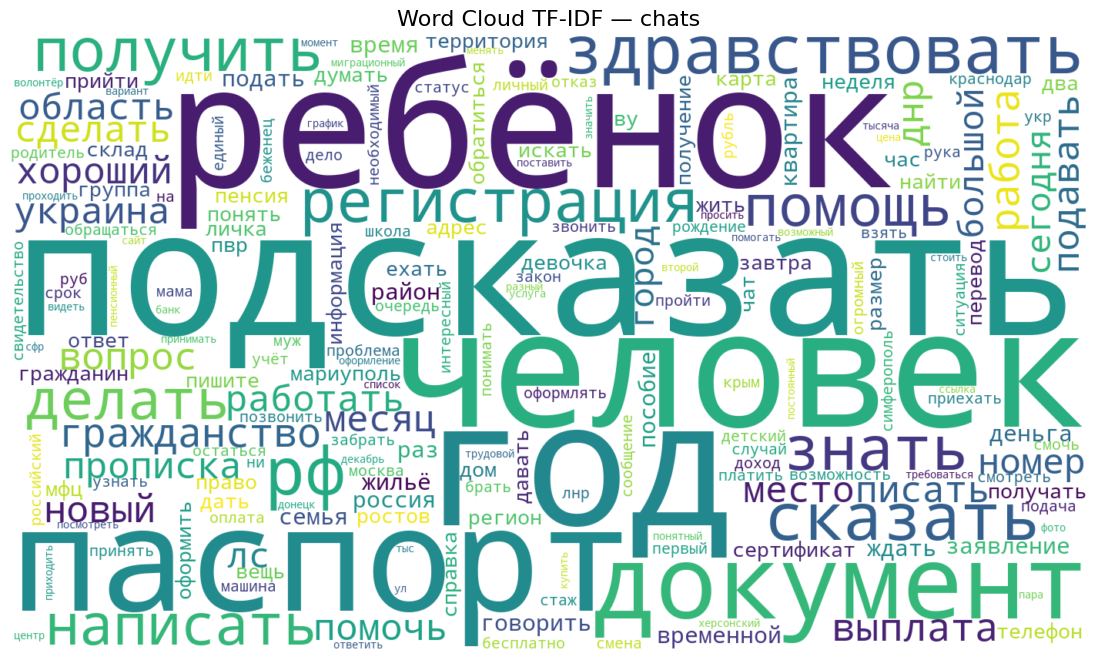

In [8]:
df_top_chats = tfidf_wordcloud_for_corpus(Path("chats"), top_n=30)

#### Application aux espaces d’activité bénévole

Cette cellule applique la même exploration lexicale au corpus exploratoire des espaces bénévoles. Ces résultats permettent une comparaison générale avec les chats, même si l’analyse principale se concentre ensuite sur ces derniers.


===== activites_benevoles =====
Nombre de documents: 103537

Top mots TF-IDF :


,term,mean_tfidf
0,помощь,0.024978
1,человек,0.017968
2,здравствовать,0.017587
3,ребёнок,0.017534
4,подсказать,0.015139
5,помочь,0.014530
6,год,0.013783
7,вещь,0.012815
8,семья,0.012637
9,склад,0.011855


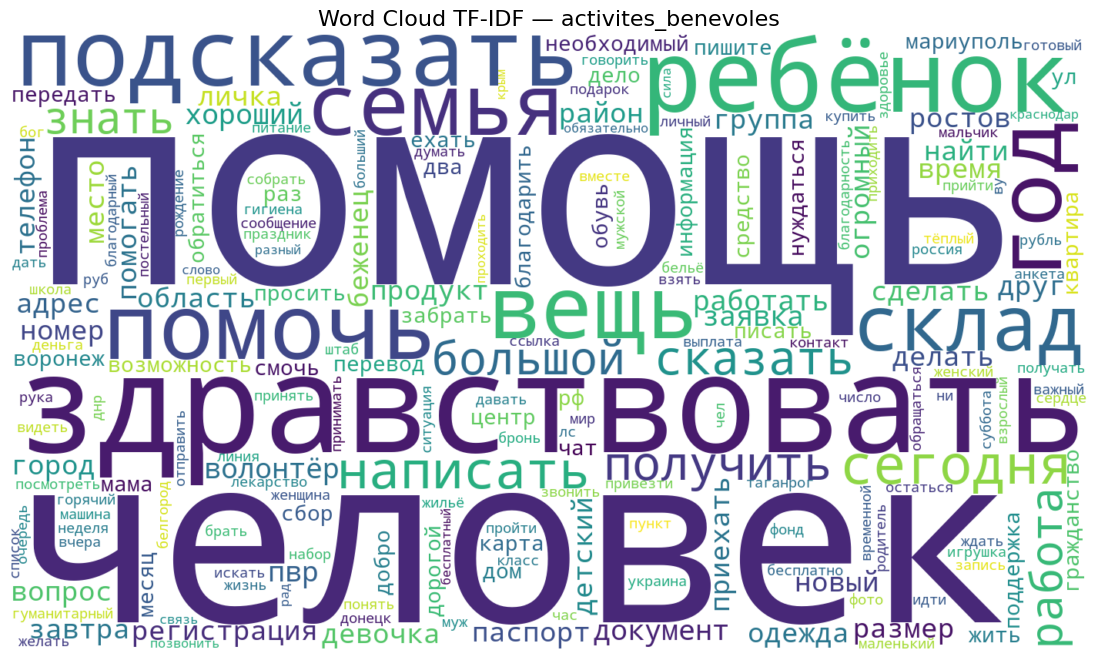

In [81]:
df_top_activites = tfidf_wordcloud_for_corpus(Path("activites_benevoles"), top_n=30)